In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mimino12/resting-loso-output/TCN_FFNN_LOSO_folds.csv
/kaggle/input/datasets/mimino12/resting-loso-output/TCN_FFNN_LOSO_summary.csv
/kaggle/input/datasets/mimino12/resting-loso-output/TCN_v3_LOSO_folds.csv
/kaggle/input/datasets/mimino12/resting-loso-output/TCN_v3_LOSO_summary.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/

# MODMA Resting-state — LOSO v4

Five remaining models are in completely separate run cells:

1. CNN
2. TCN + FFNN
3. CNN + LSTM
4. 2D-CNN + LSTM
5. MC Dropout + TCN

The shared helper cell contains the strict subject-level LOSO procedure only.
Each model cell defines its own architecture and runs independently.

This keeps the successful TCN-v3 principles:
- 384 temporally distributed windows per subject
- strict outer LOSO
- inner subject-level validation
- fold-only preprocessing
- temporal demeaning + train-fold scaling
- tempered subject-level class weights
- subject-level epoch selection
- robust subject probability aggregation
- final retraining on all non-test subjects
- resume support

For the remaining models, threshold calibration is stabilized to 0.40–0.70 with
a small penalty for moving too far from 0.50, because the TCN-v3 confusion matrix
showed strong MDD sensitivity but weak HC specificity.

In [3]:
import os, re, gc, time, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, f1_score,
    confusion_matrix, roc_auc_score, roc_curve
)

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception:
        pass

print("TensorFlow:", tf.__version__)
print("GPU(s):", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU(s): []


2026-09-17 17:59:54.680034: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Setup, Save, and LOSO-ready cache
Same 384-window resting-state cache design as TCN v3.

In [14]:
# ============================================================
# SETUP, SAVE, AND PREPARE LOSO-READY CACHE
# RESTING-STATE — SEGMENT-SAFE + SUBJECT-BALANCED
# ============================================================

from pathlib import Path
from collections import defaultdict
import re
import gc

import numpy as np
import pandas as pd
from sklearn.model_selection import LeaveOneGroupOut


# ------------------------------------------------------------
# A. CONFIGURATION
# ------------------------------------------------------------

PARADIGM = "Resting-state"

DATA_DIR = Path(
    "/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/"
    "mat-csv-actual/mat-csv-actual/csv_files_from_mat2"
)

OUTPUT_ROOT = Path("/kaggle/working/LOSO_Q1_resting")
RESULTS_ROOT = OUTPUT_ROOT / "model_results"

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

FS = 250.0
WINDOW_SIZE = 250       # 1 second
STRIDE = 125            # 50% overlap

# Fast Q1 revision mode.
# Change to None only for a later full-window rerun.
MAX_WINDOWS_PER_SUBJECT = 384

CACHE_PATH = OUTPUT_ROOT / (
    f"resting_LOSO_raw_{MAX_WINDOWS_PER_SUBJECT}w_per_subject.npz"
)

LABEL_NAMES = {0: "HC", 1: "MDD"}

print("DATA_DIR:", DATA_DIR)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("CACHE_PATH:", CACHE_PATH)
print("MAX_WINDOWS_PER_SUBJECT:", MAX_WINDOWS_PER_SUBJECT)


# ------------------------------------------------------------
# B. SUBJECT / LABEL PARSING
# ------------------------------------------------------------

def parse_subject_label(filename):
    """
    Final binary rule:
      0201_xxxx -> MDD = 1
      0203_xxxx -> HC  = 0
      0202_xxxx -> excluded
    """
    m = re.search(
        r"(020[123])[-_]?(\d+)",
        Path(filename).stem
    )

    if not m:
        return None, None, None

    code = m.group(1)
    subject = f"{code}_{m.group(2)}"

    if code == "0201":
        return subject, 1, code

    if code == "0203":
        return subject, 0, code

    return subject, None, code


# ------------------------------------------------------------
# C. EEG COLUMN DETECTION
# ------------------------------------------------------------

def detect_eeg_columns(columns):
    found = {}

    for col in columns:
        m = re.match(
            r"^(?:EEG[\s_-]*|E[\s_-]*)(\d{1,3})$",
            str(col).strip(),
            re.I
        )

        if m:
            n = int(m.group(1))
            if 1 <= n <= 128:
                found[n] = col

    if len(found) < 100:
        raise ValueError(
            f"Only {len(found)} EEG columns found. "
            f"First columns: {list(columns)[:15]}"
        )

    return [found[k] for k in sorted(found)]


# ------------------------------------------------------------
# D. WINDOW HELPERS
# ------------------------------------------------------------

def available_window_starts(n_samples, window_size, stride):
    if n_samples < window_size:
        return np.array([], dtype=int)

    return np.arange(
        0,
        n_samples - window_size + 1,
        stride,
        dtype=int
    )


def extract_selected_windows(arr, starts, window_size):
    if len(starts) == 0:
        return np.empty(
            (0, window_size, arr.shape[1]),
            dtype=np.float32
        )

    return np.stack(
        [arr[s:s + window_size] for s in starts],
        axis=0
    ).astype(np.float32)


def validate_groups(y, groups):
    for subject in np.unique(groups):
        labs = np.unique(y[groups == subject])
        assert len(labs) == 1, (subject, labs)


def make_subject_table(X, y, groups):
    subjects = np.unique(groups)

    table = pd.DataFrame({
        "subject": subjects,
        "label": [
            int(y[groups == s][0])
            for s in subjects
        ],
        "diagnosis": [
            LABEL_NAMES[int(y[groups == s][0])]
            for s in subjects
        ],
        "n_windows": [
            int(np.sum(groups == s))
            for s in subjects
        ]
    })

    print("\nX shape:", X.shape)
    print("Subjects:", len(table))
    print("\nSubject-level class counts:")
    print(table["diagnosis"].value_counts())

    display(table)
    return table


# ------------------------------------------------------------
# E. LOAD CACHE IF IT ALREADY EXISTS
# ------------------------------------------------------------

if CACHE_PATH.exists():

    z = np.load(CACHE_PATH, allow_pickle=True)

    X = z["X"].astype(np.float32)
    y = z["y"].astype(np.int8)
    groups = z["groups"].astype(str)
    channel_names = z["channel_names"].astype(str)

    print("\nLoaded existing LOSO-ready cache:")
    print(CACHE_PATH)

else:

    # --------------------------------------------------------
    # F. DISCOVER CSV FILES
    # --------------------------------------------------------

    csv_files = sorted(DATA_DIR.glob("*.csv"))

    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in {DATA_DIR}"
        )


    # --------------------------------------------------------
    # G. GROUP PHYSICAL CSV FILES BY SUBJECT
    # --------------------------------------------------------

    subject_files = defaultdict(list)
    subject_labels = {}

    for path in csv_files:

        subject, label, code = parse_subject_label(path.name)

        if label is None:
            continue

        subject_files[subject].append(path)
        subject_labels[subject] = int(label)


    print("\nSubjects discovered:", len(subject_files))


    # --------------------------------------------------------
    # H. BUILD UP TO 384 WINDOWS PER SUBJECT
    #
    # IMPORTANT:
    # 1) windows never cross a CSV boundary;
    # 2) files are NOT capped separately;
    # 3) selection is uniform across the subject's entire
    #    collection of legal windows.
    # --------------------------------------------------------

    X_parts = []
    y_parts = []
    group_parts = []

    channel_names = None


    for subject_i, subject in enumerate(
        sorted(subject_files),
        start=1
    ):

        files_for_subject = subject_files[subject]
        segment_info = []


        # Pass 1: count all valid windows in every physical file.
        for path in files_for_subject:

            df = pd.read_csv(path)

            eeg_cols = detect_eeg_columns(df.columns)

            if channel_names is None:
                channel_names = np.asarray(
                    [str(c) for c in eeg_cols],
                    dtype=str
                )

            if len(eeg_cols) != len(channel_names):
                raise ValueError(
                    f"{path.name}: {len(eeg_cols)} channels; "
                    f"expected {len(channel_names)}"
                )

            starts = available_window_starts(
                n_samples=len(df),
                window_size=WINDOW_SIZE,
                stride=STRIDE
            )

            segment_info.append({
                "path": path,
                "eeg_cols": eeg_cols,
                "starts": starts,
                "n_windows": len(starts)
            })

            del df
            gc.collect()


        total_available = sum(
            info["n_windows"]
            for info in segment_info
        )

        if total_available == 0:
            print("Skipping", subject, "- no legal windows")
            continue


        if MAX_WINDOWS_PER_SUBJECT is None:
            n_keep = total_available
        else:
            n_keep = min(
                int(MAX_WINDOWS_PER_SUBJECT),
                total_available
            )


        # Deterministic selection across the subject's FULL window pool.
        selected_global = np.linspace(
            0,
            total_available - 1,
            n_keep,
            dtype=int
        )


        selected_windows = []
        cumulative_start = 0


        # Pass 2: load only the files that contain selected windows.
        for info in segment_info:

            n_seg = info["n_windows"]
            cumulative_end = cumulative_start + n_seg

            mask = (
                (selected_global >= cumulative_start)
                &
                (selected_global < cumulative_end)
            )

            selected_local = (
                selected_global[mask]
                -
                cumulative_start
            )


            if len(selected_local) > 0:

                df = pd.read_csv(info["path"])

                arr = (
                    df[info["eeg_cols"]]
                    .apply(pd.to_numeric, errors="coerce")
                    .to_numpy(dtype=np.float32)
                )

                actual_starts = info["starts"][selected_local]

                w = extract_selected_windows(
                    arr=arr,
                    starts=actual_starts,
                    window_size=WINDOW_SIZE
                )

                selected_windows.append(w)

                del df, arr, w
                gc.collect()


            cumulative_start = cumulative_end


        subject_X = np.concatenate(
            selected_windows,
            axis=0
        ).astype(np.float32)


        assert len(subject_X) == n_keep, (
            subject,
            len(subject_X),
            n_keep
        )


        label = subject_labels[subject]

        X_parts.append(subject_X)

        y_parts.append(
            np.full(
                len(subject_X),
                label,
                dtype=np.int8
            )
        )

        group_parts.append(
            np.full(
                len(subject_X),
                subject,
                dtype=object
            )
        )


        print(
            f"{subject_i:02d} | "
            f"{subject:12s} | "
            f"{LABEL_NAMES[label]:3s} | "
            f"available={total_available:4d} | "
            f"kept={len(subject_X):3d} | "
            f"files={len(files_for_subject)}"
        )


    # --------------------------------------------------------
    # I. CREATE ONE UNSPLIT LOSO DATASET
    # --------------------------------------------------------

    X = np.concatenate(
        X_parts,
        axis=0
    ).astype(np.float32)

    y = np.concatenate(
        y_parts
    ).astype(np.int8)

    groups = np.concatenate(
        group_parts
    ).astype(str)

    channel_names = np.asarray(
        channel_names,
        dtype=str
    )


    assert len(X) == len(y) == len(groups)

    validate_groups(y, groups)


    # --------------------------------------------------------
    # J. VERIFY THE OUTER LOSO STRUCTURE BEFORE SAVING
    # --------------------------------------------------------

    logo = LeaveOneGroupOut()
    n_folds = 0

    for train_idx, test_idx in logo.split(X, y, groups):

        train_subjects = set(groups[train_idx])
        test_subjects = set(groups[test_idx])

        assert train_subjects.isdisjoint(test_subjects)
        assert len(test_subjects) == 1

        n_folds += 1


    print("\nVerified LOSO folds:", n_folds)
    print("No subject leakage detected.")


    # --------------------------------------------------------
    # K. SAVE ONE UNSPLIT LOSO-READY CACHE
    #
    # DO NOT save one fixed X_train/X_test here.
    # Each model cell creates the LOSO split dynamically.
    # --------------------------------------------------------

    np.savez_compressed(
        CACHE_PATH,
        X=X,
        y=y,
        groups=groups,
        channel_names=channel_names,
        fs=np.asarray(FS, dtype=np.float32),
        max_windows_per_subject=np.asarray(
            -1
            if MAX_WINDOWS_PER_SUBJECT is None
            else MAX_WINDOWS_PER_SUBJECT,
            dtype=np.int32
        )
    )


    print("\nSaved LOSO-ready cache:")
    print(CACHE_PATH)


# ------------------------------------------------------------
# L. FINAL TABLE + LOSO VALIDATION
# ------------------------------------------------------------

subject_table = make_subject_table(
    X,
    y,
    groups
)


logo = LeaveOneGroupOut()
n_folds = 0

for train_idx, test_idx in logo.split(X, y, groups):

    train_subjects = set(groups[train_idx])
    test_subjects = set(groups[test_idx])

    assert train_subjects.isdisjoint(test_subjects)
    assert len(test_subjects) == 1

    n_folds += 1


print("\nLOSO folds:", n_folds)
print("No subject leakage detected.")


if CACHE_PATH.exists():
    print(
        "\nCompressed cache size:",
        f"{CACHE_PATH.stat().st_size / (1024**2):.1f} MiB"
    )


# Expected fast-mode result for your current resting-state subset:
# X approximately: (13440, 250, 128) when all 35 subjects have >=384 legal windows
# Subjects: 35
# MDD: 22
# HC: 13
# LOSO folds: 35

DATA_DIR: /kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2
OUTPUT_ROOT: /kaggle/working/LOSO_Q1_resting
RESULTS_ROOT: /kaggle/working/LOSO_Q1_resting/model_results
CACHE_PATH: /kaggle/working/LOSO_Q1_resting/resting_LOSO_raw_384w_per_subject.npz
MAX_WINDOWS_PER_SUBJECT: 384

Loaded existing LOSO-ready cache:
/kaggle/working/LOSO_Q1_resting/resting_LOSO_raw_384w_per_subject.npz

X shape: (13440, 250, 128)
Subjects: 35

Subject-level class counts:
diagnosis
MDD    22
HC     13
Name: count, dtype: int64


,subject,label,diagnosis,n_windows
0,0201_0002,1,MDD,384
1,0201_0004,1,MDD,384
2,0201_0005,1,MDD,384
3,0201_0006,1,MDD,384
4,0201_0008,1,MDD,384
5,0201_0010,1,MDD,384
6,0201_0011,1,MDD,384
7,0201_0012,1,MDD,384
8,0201_0013,1,MDD,384
9,0201_0015,1,MDD,384



LOSO folds: 35
No subject leakage detected.

Compressed cache size: 1525.1 MiB


## Shared v4 LOSO engine
Run this once. It does not train a model.

In [15]:
# ======================================================================
# SHARED v4 LOSO ENGINE
# Run this once before any model cell.
# ======================================================================

V4_SEED = 42
V4_INNER_VAL_FRACTION = 0.30
V4_SELECTOR_EPOCHS = 25
V4_MIN_FINAL_EPOCHS = 8
V4_MAX_FINAL_EPOCHS = 25
V4_BATCH_SIZE = 64
V4_PRED_BATCH_SIZE = 128
V4_WEIGHT_DECAY = 1e-4
V4_LABEL_SMOOTHING = 0.02
V4_CLASS_WEIGHT_POWER = 0.50
V4_TRIM_FRACTION = 0.10
V4_THRESHOLD_GRID = np.arange(0.40, 0.701, 0.01)
V4_THRESHOLD_DISTANCE_PENALTY = 0.06
V4_FOLD_LIMIT = None
V4_MC_PASSES = 15

V4_ROOT = Path(RESULTS_ROOT) / "V4_separate_models"
V4_ROOT.mkdir(parents=True, exist_ok=True)

print("v4 output root:", V4_ROOT)


def v4_inner_subject_split(outer_train_idx, y, groups, seed):
    subjects = np.unique(groups[outer_train_idx])
    subject_labels = np.asarray(
        [int(y[groups == s][0]) for s in subjects],
        dtype=int
    )

    train_subjects, val_subjects = train_test_split(
        subjects,
        test_size=V4_INNER_VAL_FRACTION,
        random_state=seed,
        stratify=subject_labels
    )

    train_idx = outer_train_idx[
        np.isin(groups[outer_train_idx], train_subjects)
    ]
    val_idx = outer_train_idx[
        np.isin(groups[outer_train_idx], val_subjects)
    ]

    return train_idx, val_idx


def v4_fit_preprocessor(X_train_raw):
    X = np.asarray(X_train_raw, dtype=np.float32)

    flat = X.reshape(-1, X.shape[-1]).astype(np.float64)
    impute_mean = np.nanmean(flat, axis=0)
    impute_mean = np.where(
        np.isfinite(impute_mean),
        impute_mean,
        0.0
    ).astype(np.float32)

    Xf = X.copy()

    for c in range(Xf.shape[-1]):
        bad = ~np.isfinite(Xf[..., c])
        if np.any(bad):
            Xf[..., c][bad] = impute_mean[c]

    Xf = Xf - Xf.mean(axis=1, keepdims=True)

    channel_sd = np.std(
        Xf.reshape(-1, Xf.shape[-1]),
        axis=0
    )
    channel_sd = np.where(
        (~np.isfinite(channel_sd)) | (channel_sd < 1e-7),
        1.0,
        channel_sd
    ).astype(np.float32)

    return impute_mean, channel_sd


def v4_transform(X_raw, impute_mean, channel_sd):
    X = np.asarray(X_raw, dtype=np.float32).copy()

    for c in range(X.shape[-1]):
        bad = ~np.isfinite(X[..., c])
        if np.any(bad):
            X[..., c][bad] = impute_mean[c]

    X = X - X.mean(axis=1, keepdims=True)
    X = X / channel_sd[None, None, :]
    X = np.clip(X, -6.0, 6.0)

    return np.nan_to_num(
        X,
        nan=0.0,
        posinf=6.0,
        neginf=-6.0
    ).astype(np.float32)


def v4_subject_class_weights(y_train, groups_train):
    subjects = np.unique(groups_train)
    subject_labels = np.asarray(
        [int(y_train[groups_train == s][0]) for s in subjects],
        dtype=int
    )

    classes = np.asarray([0, 1], dtype=int)

    raw = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=subject_labels
    )

    weights = np.power(
        raw,
        V4_CLASS_WEIGHT_POWER
    )
    weights = weights / np.mean(weights)

    return {
        int(c): float(w)
        for c, w in zip(classes, weights)
    }


def v4_trimmed_mean(values, trim_fraction=V4_TRIM_FRACTION):
    a = np.sort(np.asarray(values, dtype=float))

    if len(a) == 0:
        return np.nan

    k = int(np.floor(trim_fraction * len(a)))

    if k > 0 and 2*k < len(a):
        a = a[k:-k]

    return float(np.mean(a))


def v4_subject_table(prob, y, groups):
    rows = []

    for subject in np.unique(groups):
        mask = groups == subject

        rows.append({
            "subject": str(subject),
            "label": int(y[mask][0]),
            "prob": v4_trimmed_mean(prob[mask]),
            "n_windows": int(np.sum(mask))
        })

    return pd.DataFrame(rows)


def v4_calibrate_threshold(subject_df):
    yt = subject_df["label"].to_numpy(dtype=int)
    pr = subject_df["prob"].to_numpy(dtype=float)

    if len(np.unique(yt)) < 2:
        return 0.50, np.nan, np.nan

    bal_scores = []
    reg_scores = []

    for threshold in V4_THRESHOLD_GRID:
        pred = (pr >= threshold).astype(int)

        bal = balanced_accuracy_score(yt, pred)

        reg = (
            bal
            -
            V4_THRESHOLD_DISTANCE_PENALTY
            *
            abs(float(threshold) - 0.50)
        )

        bal_scores.append(bal)
        reg_scores.append(reg)

    bal_scores = np.asarray(bal_scores, dtype=float)
    reg_scores = np.asarray(reg_scores, dtype=float)

    best = np.flatnonzero(
        np.isclose(reg_scores, reg_scores.max())
    )

    chosen = best[
        np.argmin(
            np.abs(
                V4_THRESHOLD_GRID[best] - 0.50
            )
        )
    ]

    return (
        float(V4_THRESHOLD_GRID[chosen]),
        float(bal_scores[chosen]),
        float(reg_scores[chosen])
    )


class V4MCDropout(layers.Dropout):
    def __init__(self, rate, **kwargs):
        super().__init__(rate, **kwargs)
        self.mc_enabled = False

    def call(self, inputs, training=None):
        if self.mc_enabled:
            training = True
        return super().call(inputs, training=training)


class V4MCSpatialDropout1D(layers.SpatialDropout1D):
    def __init__(self, rate, **kwargs):
        super().__init__(rate, **kwargs)
        self.mc_enabled = False

    def call(self, inputs, training=None):
        if self.mc_enabled:
            training = True
        return super().call(inputs, training=training)


def v4_set_mc_mode(model, enabled):
    for layer in model.layers:
        if isinstance(
            layer,
            (V4MCDropout, V4MCSpatialDropout1D)
        ):
            layer.mc_enabled = bool(enabled)


def v4_mc_predict(
    model,
    X,
    passes=V4_MC_PASSES,
    batch_size=V4_PRED_BATCH_SIZE
):
    v4_set_mc_mode(model, True)

    predictions = []

    for _ in range(passes):
        chunks = []

        for start in range(0, len(X), batch_size):
            xb = tf.convert_to_tensor(
                X[start:start+batch_size],
                dtype=tf.float32
            )

            chunks.append(
                model(
                    xb,
                    training=False
                ).numpy().ravel()
            )

        predictions.append(np.concatenate(chunks))

    v4_set_mc_mode(model, False)

    arr = np.stack(predictions, axis=0)

    return arr.mean(axis=0), arr.var(axis=0)


class V4SubjectValidation(callbacks.Callback):
    def __init__(
        self,
        X_val,
        y_val,
        groups_val,
        use_mc=False
    ):
        super().__init__()

        self.X_val = X_val
        self.y_val = y_val
        self.groups_val = groups_val
        self.use_mc = use_mc

        self.best_score = -np.inf
        self.best_epoch = 1
        self.best_threshold = 0.50
        self.best_auc = np.nan
        self.best_balanced_accuracy = np.nan
        self.rows = []

    def on_epoch_end(self, epoch, logs=None):
        if self.use_mc:
            v4_set_mc_mode(self.model, False)

        prob = self.model.predict(
            self.X_val,
            batch_size=V4_PRED_BATCH_SIZE,
            verbose=0
        ).ravel()

        sd = v4_subject_table(
            prob,
            self.y_val,
            self.groups_val
        )

        yt = sd["label"].to_numpy(dtype=int)
        pr = sd["prob"].to_numpy(dtype=float)

        auc = (
            roc_auc_score(yt, pr)
            if len(np.unique(yt)) == 2
            else np.nan
        )

        threshold, bal, threshold_score = v4_calibrate_threshold(sd)

        if np.isfinite(auc):
            selection_score = (
                0.70 * auc
                +
                0.30 * threshold_score
            )
        else:
            selection_score = threshold_score

        self.rows.append({
            "epoch": int(epoch + 1),
            "subject_auc": float(auc),
            "subject_balanced_accuracy": float(bal),
            "threshold": float(threshold),
            "threshold_regularized_score": float(threshold_score),
            "selection_score": float(selection_score),
            "window_val_loss": float(
                logs.get("val_loss", np.nan)
                if logs
                else np.nan
            )
        })

        print(
            f"  inner epoch {epoch+1:02d}: "
            f"AUC={auc:.3f} "
            f"BalAcc={bal:.3f} "
            f"thr={threshold:.2f} "
            f"score={selection_score:.3f}"
        )

        if selection_score > self.best_score + 1e-4:
            self.best_score = float(selection_score)
            self.best_epoch = int(epoch + 1)
            self.best_threshold = float(threshold)
            self.best_auc = float(auc)
            self.best_balanced_accuracy = float(bal)


def v4_compile(model, learning_rate):
    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=V4_WEIGHT_DECAY,
            clipnorm=1.0
        )
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(
            label_smoothing=V4_LABEL_SMOOTHING
        ),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(name="accuracy"),
            tf.keras.metrics.AUC(name="auc")
        ]
    )

    return model


def v4_wilson(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    den = 1 + z*z/n
    centre = (p + z*z/(2*n)) / den

    half = (
        z
        *
        np.sqrt(
            (
                p*(1-p)
                +
                z*z/(4*n)
            )
            /
            n
        )
        /
        den
    )

    return (
        float(max(0.0, centre-half)),
        float(min(1.0, centre+half))
    )


def v4_save_plots(
    folds_df,
    summary_df,
    model_dir,
    model_name
):
    safe = (
        model_name
        .replace("+", "_")
        .replace(" ", "_")
        .replace("-", "_")
    )

    s = summary_df.iloc[0]

    rows = [
        ["LOSO subject accuracy", f"{100*s['LOSO_subject_accuracy']:.2f}%"],
        [
            "Accuracy 95% CI",
            f"{100*s['accuracy_CI95_low']:.2f}%–"
            f"{100*s['accuracy_CI95_high']:.2f}%"
        ],
        ["Sensitivity (MDD)", f"{100*s['sensitivity_MDD']:.2f}%"],
        [
            "Sensitivity 95% CI",
            f"{100*s['sensitivity_CI95_low']:.2f}%–"
            f"{100*s['sensitivity_CI95_high']:.2f}%"
        ],
        ["Specificity (HC)", f"{100*s['specificity_HC']:.2f}%"],
        [
            "Specificity 95% CI",
            f"{100*s['specificity_CI95_low']:.2f}%–"
            f"{100*s['specificity_CI95_high']:.2f}%"
        ],
        ["Balanced accuracy", f"{100*s['balanced_accuracy']:.2f}%"],
        ["MDD F1", f"{s['F1_MDD']:.3f}"],
        ["Subject AUC", f"{s['subject_ROC_AUC']:.3f}"],
        [
            "Fold window accuracy mean",
            f"{100*s['heldout_window_accuracy_mean']:.2f}%"
        ],
        [
            "Fold window accuracy SD",
            f"{100*s['heldout_window_accuracy_SD']:.2f}%"
        ],
    ]

    fig, ax = plt.subplots(figsize=(8.8, 5.8))
    ax.axis("off")

    tab = ax.table(
        cellText=rows,
        colLabels=["Reviewer parameter", "LOSO result"],
        loc="center",
        cellLoc="left"
    )

    tab.auto_set_font_size(False)
    tab.set_fontsize(10)
    tab.scale(1, 1.45)

    ax.set_title(
        f"Resting-state: {model_name} Strict LOSO-CV",
        pad=18
    )

    plt.tight_layout()

    plt.savefig(
        model_dir / f"{safe}_LOSO_summary.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

    yt = folds_df["label"].to_numpy(dtype=int)
    yp = folds_df["subject_pred"].to_numpy(dtype=int)
    pr = folds_df["subject_prob"].to_numpy(dtype=float)

    cm = confusion_matrix(
        yt,
        yp,
        labels=[0, 1]
    )

    plt.figure(figsize=(5, 4.5))
    plt.imshow(cm)

    for (i, j), value in np.ndenumerate(cm):
        plt.text(
            j,
            i,
            str(value),
            ha="center",
            va="center",
            fontsize=14
        )

    plt.xticks([0, 1], ["HC", "MDD"])
    plt.yticks([0, 1], ["HC", "MDD"])
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(f"{model_name}: subject-level LOSO")
    plt.tight_layout()

    plt.savefig(
        model_dir / f"{safe}_LOSO_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()

    if len(np.unique(yt)) == 2:
        fpr, tpr, _ = roc_curve(yt, pr)
        auc = roc_auc_score(yt, pr)

        plt.figure(figsize=(5, 5))
        plt.plot(
            fpr,
            tpr,
            label=f"AUC = {auc:.3f}"
        )
        plt.plot([0, 1], [0, 1], linestyle="--")
        plt.xlabel("False positive rate")
        plt.ylabel("True positive rate")
        plt.title(f"{model_name}: subject-level LOSO ROC")
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            model_dir / f"{safe}_LOSO_ROC.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.close()

    d = (
        folds_df
        .sort_values(["label", "subject"])
        .reset_index(drop=True)
    )

    plt.figure(
        figsize=(
            max(10, len(d)*0.32),
            5
        )
    )

    plt.bar(
        np.arange(len(d)),
        100*d["window_accuracy"]
    )

    plt.axhline(
        50,
        linestyle="--",
        linewidth=1
    )

    plt.xticks(
        np.arange(len(d)),
        d["subject"],
        rotation=90,
        fontsize=7
    )

    plt.ylabel("Held-out subject window accuracy (%)")
    plt.xlabel("LOSO held-out subject")
    plt.title(f"{model_name}: LOSO fold variability")
    plt.tight_layout()

    plt.savefig(
        model_dir / f"{safe}_LOSO_fold_accuracy.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.close()


def run_v4_loso(
    model_name,
    build_model_fn,
    learning_rate,
    use_mc=False,
    final_verbose=2
):
    safe = (
        model_name
        .replace("+", "_")
        .replace(" ", "_")
        .replace("-", "_")
    )

    model_dir = V4_ROOT / safe
    model_dir.mkdir(parents=True, exist_ok=True)

    fold_csv = model_dir / f"{safe}_LOSO_folds.csv"
    summary_csv = model_dir / f"{safe}_LOSO_summary.csv"
    history_csv = model_dir / f"{safe}_inner_subject_validation_history.csv"

    if fold_csv.exists():
        folds_df = pd.read_csv(fold_csv)
        completed = set(folds_df["subject"].astype(str))

        print(
            f"{model_name}: resuming "
            f"{len(completed)} completed folds."
        )
    else:
        folds_df = pd.DataFrame()
        completed = set()

    if history_csv.exists():
        history_all = pd.read_csv(history_csv)
    else:
        history_all = pd.DataFrame()

    logo = LeaveOneGroupOut()
    splits = list(
        logo.split(
            X,
            y,
            groups
        )
    )

    if V4_FOLD_LIMIT is not None:
        splits = splits[:int(V4_FOLD_LIMIT)]
        print(
            "WARNING: V4_FOLD_LIMIT active; "
            "not a final reviewer run."
        )

    call_start = time.time()

    for fold, (outer_train_idx, outer_test_idx) in enumerate(
        splits,
        start=1
    ):
        test_subject = str(
            np.unique(
                groups[outer_test_idx]
            )[0]
        )

        if test_subject in completed:
            print(
                f"[skip] {model_name} "
                f"fold {fold:02d}: {test_subject}"
            )
            continue

        print("\n" + "=" * 78)
        print(
            f"{model_name} OUTER FOLD "
            f"{fold:02d}/{len(splits):02d} "
            f"| held out={test_subject} "
            f"| true={LABEL_NAMES[int(y[outer_test_idx][0])]}"
        )
        print("=" * 78)

        train_subjects = set(groups[outer_train_idx])
        test_subjects = set(groups[outer_test_idx])

        assert train_subjects.isdisjoint(test_subjects)
        assert len(test_subjects) == 1

        # ---------- INNER MODEL SELECTION ----------
        inner_train_idx, inner_val_idx = v4_inner_subject_split(
            outer_train_idx,
            y,
            groups,
            seed=V4_SEED + fold
        )

        X_itr_raw = X[inner_train_idx]
        X_iva_raw = X[inner_val_idx]
        y_itr = y[inner_train_idx].astype(int)
        y_iva = y[inner_val_idx].astype(int)
        g_itr = groups[inner_train_idx]
        g_iva = groups[inner_val_idx]

        imp_mean, scale_sd = v4_fit_preprocessor(
            X_itr_raw
        )

        X_itr = v4_transform(
            X_itr_raw,
            imp_mean,
            scale_sd
        )

        X_iva = v4_transform(
            X_iva_raw,
            imp_mean,
            scale_sd
        )

        inner_weights = v4_subject_class_weights(
            y_itr,
            g_itr
        )

        tf.keras.backend.clear_session()

        np.random.seed(V4_SEED + fold)
        tf.random.set_seed(V4_SEED + fold)

        selector = build_model_fn(
            (
                X_itr.shape[1],
                X_itr.shape[2]
            ),
            learning_rate
        )

        subject_callback = V4SubjectValidation(
            X_iva,
            y_iva,
            g_iva,
            use_mc=use_mc
        )

        selector.fit(
            X_itr,
            y_itr,
            validation_data=(
                X_iva,
                y_iva
            ),
            epochs=V4_SELECTOR_EPOCHS,
            batch_size=V4_BATCH_SIZE,
            class_weight=inner_weights,
            shuffle=True,
            callbacks=[
                subject_callback,
                callbacks.TerminateOnNaN()
            ],
            verbose=0
        )

        best_epoch = int(
            np.clip(
                subject_callback.best_epoch,
                V4_MIN_FINAL_EPOCHS,
                V4_MAX_FINAL_EPOCHS
            )
        )

        threshold = float(
            subject_callback.best_threshold
        )

        print("\nInner selection:")
        print("  raw best epoch:", subject_callback.best_epoch)
        print("  final epochs:", best_epoch)
        print(
            "  inner subject AUC:",
            f"{subject_callback.best_auc:.3f}"
        )
        print(
            "  inner balanced accuracy:",
            f"{subject_callback.best_balanced_accuracy:.3f}"
        )
        print("  threshold:", f"{threshold:.2f}")

        hist = pd.DataFrame(subject_callback.rows)
        hist.insert(0, "subject", test_subject)
        hist.insert(0, "fold", fold)

        history_all = pd.concat(
            [history_all, hist],
            ignore_index=True
        )

        history_all = history_all.drop_duplicates(
            subset=["subject", "epoch"],
            keep="last"
        )

        history_all.to_csv(
            history_csv,
            index=False
        )

        del selector
        del X_itr, X_iva
        del X_itr_raw, X_iva_raw

        gc.collect()
        tf.keras.backend.clear_session()

        # ---------- FINAL OUTER-FOLD TRAINING ----------
        X_outer_train_raw = X[outer_train_idx]
        X_outer_test_raw = X[outer_test_idx]

        y_outer_train = y[outer_train_idx].astype(int)
        y_outer_test = y[outer_test_idx].astype(int)

        g_outer_train = groups[outer_train_idx]

        outer_imp, outer_sd = v4_fit_preprocessor(
            X_outer_train_raw
        )

        X_outer_train = v4_transform(
            X_outer_train_raw,
            outer_imp,
            outer_sd
        )

        X_outer_test = v4_transform(
            X_outer_test_raw,
            outer_imp,
            outer_sd
        )

        outer_weights = v4_subject_class_weights(
            y_outer_train,
            g_outer_train
        )

        tf.keras.backend.clear_session()

        np.random.seed(
            1000 + V4_SEED + fold
        )
        tf.random.set_seed(
            1000 + V4_SEED + fold
        )

        final_model = build_model_fn(
            (
                X_outer_train.shape[1],
                X_outer_train.shape[2]
            ),
            learning_rate
        )

        print(
            f"\nVisible final training: "
            f"{best_epoch} epochs"
        )

        final_model.fit(
            X_outer_train,
            y_outer_train,
            epochs=best_epoch,
            batch_size=V4_BATCH_SIZE,
            class_weight=outer_weights,
            shuffle=True,
            callbacks=[
                callbacks.TerminateOnNaN()
            ],
            verbose=final_verbose
        )

        # ---------- OUTER TEST ----------
        if use_mc:
            test_prob_windows, test_var_windows = v4_mc_predict(
                final_model,
                X_outer_test
            )
            mc_uncertainty = float(
                np.mean(test_var_windows)
            )
        else:
            test_prob_windows = final_model.predict(
                X_outer_test,
                batch_size=V4_PRED_BATCH_SIZE,
                verbose=0
            ).ravel()
            mc_uncertainty = np.nan

        subject_prob = v4_trimmed_mean(
            test_prob_windows
        )

        subject_pred = int(
            subject_prob >= threshold
        )

        true_label = int(
            y_outer_test[0]
        )

        window_pred = (
            test_prob_windows >= threshold
        ).astype(int)

        window_acc = float(
            accuracy_score(
                y_outer_test,
                window_pred
            )
        )

        print("\nHELD-OUT RESULT:")
        print(" subject:", test_subject)
        print(" true:", LABEL_NAMES[true_label])
        print(" MDD probability:", f"{subject_prob:.4f}")
        print(" threshold:", f"{threshold:.2f}")
        print(" predicted:", LABEL_NAMES[subject_pred])
        print(
            " correct:",
            bool(subject_pred == true_label)
        )
        print(
            " window accuracy:",
            f"{100*window_acc:.2f}%"
        )

        row = pd.DataFrame([{
            "fold": fold,
            "subject": test_subject,
            "label": true_label,
            "diagnosis": LABEL_NAMES[true_label],
            "n_test_windows": int(len(y_outer_test)),
            "window_accuracy": window_acc,
            "subject_prob": float(subject_prob),
            "subject_pred": int(subject_pred),
            "subject_correct": int(
                subject_pred == true_label
            ),
            "inner_selected_threshold": threshold,
            "inner_best_epoch_raw": int(
                subject_callback.best_epoch
            ),
            "final_epochs": int(best_epoch),
            "inner_subject_AUC": float(
                subject_callback.best_auc
            ),
            "inner_subject_balanced_accuracy": float(
                subject_callback.best_balanced_accuracy
            ),
            "class_weight_HC": float(outer_weights[0]),
            "class_weight_MDD": float(outer_weights[1]),
            "MC_mean_predictive_variance": mc_uncertainty
        }])

        folds_df = pd.concat(
            [folds_df, row],
            ignore_index=True
        )

        folds_df = (
            folds_df
            .drop_duplicates(
                subset=["subject"],
                keep="last"
            )
            .sort_values("fold")
            .reset_index(drop=True)
        )

        folds_df.to_csv(
            fold_csv,
            index=False
        )

        del final_model
        del X_outer_train, X_outer_test
        del X_outer_train_raw, X_outer_test_raw

        gc.collect()
        tf.keras.backend.clear_session()

    # ---------- REVIEWER METRICS ----------
    yt = folds_df["label"].to_numpy(dtype=int)
    yp = folds_df["subject_pred"].to_numpy(dtype=int)
    pr = folds_df["subject_prob"].to_numpy(dtype=float)

    tn, fp, fn, tp = confusion_matrix(
        yt,
        yp,
        labels=[0, 1]
    ).ravel()

    n = len(yt)
    n_mdd = tp + fn
    n_hc = tn + fp

    accuracy = (tp + tn) / n
    sensitivity = (
        tp / n_mdd
        if n_mdd
        else np.nan
    )
    specificity = (
        tn / n_hc
        if n_hc
        else np.nan
    )

    acc_ci = v4_wilson(tp + tn, n)
    sens_ci = v4_wilson(tp, n_mdd)
    spec_ci = v4_wilson(tn, n_hc)

    auc = (
        roc_auc_score(yt, pr)
        if len(np.unique(yt)) == 2
        else np.nan
    )

    summary_df = pd.DataFrame([{
        "model": model_name,
        "paradigm": "Resting-state",
        "n_subjects": int(n),
        "n_MDD": int(n_mdd),
        "n_HC": int(n_hc),

        "LOSO_subject_accuracy": float(accuracy),
        "accuracy_CI95_low": acc_ci[0],
        "accuracy_CI95_high": acc_ci[1],

        "sensitivity_MDD": float(sensitivity),
        "sensitivity_CI95_low": sens_ci[0],
        "sensitivity_CI95_high": sens_ci[1],

        "specificity_HC": float(specificity),
        "specificity_CI95_low": spec_ci[0],
        "specificity_CI95_high": spec_ci[1],

        "balanced_accuracy": float(
            balanced_accuracy_score(yt, yp)
        ),

        "precision_MDD": float(
            precision_score(
                yt,
                yp,
                pos_label=1,
                zero_division=0
            )
        ),

        "F1_MDD": float(
            f1_score(
                yt,
                yp,
                pos_label=1,
                zero_division=0
            )
        ),

        "macro_F1": float(
            f1_score(
                yt,
                yp,
                average="macro",
                zero_division=0
            )
        ),

        "subject_ROC_AUC": float(auc),

        "heldout_window_accuracy_mean": float(
            folds_df["window_accuracy"].mean()
        ),

        "heldout_window_accuracy_SD": float(
            folds_df["window_accuracy"].std(ddof=1)
        ),

        "subject_correct_indicator_SD": float(
            folds_df["subject_correct"].std(ddof=1)
        ),

        "TN_subjects": int(tn),
        "FP_subjects": int(fp),
        "FN_subjects": int(fn),
        "TP_subjects": int(tp),

        "max_windows_per_subject": (
            "ALL"
            if MAX_WINDOWS_PER_SUBJECT is None
            else int(MAX_WINDOWS_PER_SUBJECT)
        ),

        "runtime_minutes_this_call": float(
            (time.time() - call_start) / 60.0
        )
    }])

    summary_df.to_csv(
        summary_csv,
        index=False
    )

    v4_save_plots(
        folds_df,
        summary_df,
        model_dir,
        model_name
    )

    print("\nFINAL REVIEWER SUMMARY:")
    display(summary_df.T)
    print("\nSaved to:", model_dir)

    return folds_df, summary_df

v4 output root: /kaggle/working/LOSO_Q1_resting/model_results/V4_separate_models


In [16]:
TCN_SPATIAL_DROPOUT=0.25
def tcn_block(x,filters,kernel,dilation,mc=False):
    x=layers.Conv1D(filters,kernel,padding="causal",dilation_rate=dilation)(x)
    x=layers.BatchNormalization()(x); x=layers.Activation("relu")(x)
    x=(MCSpatialDropout1D(TCN_SPATIAL_DROPOUT) if mc else layers.SpatialDropout1D(TCN_SPATIAL_DROPOUT))(x)
    return x

def compile_binary(model,lr=1e-3,clipnorm=None):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr,clipnorm=clipnorm),loss="binary_crossentropy",metrics=["accuracy"],steps_per_execution=8)
    return model

In [17]:
# Ignore all warnings
import warnings
warnings.filterwarnings('ignore')

## TCN v3 — strict LOSO, subject-generalization version

Run this cell after the shared setup/cache and helper cells.

This cell deliberately writes to a new directory, so it will **not** reuse the
older 54.29% TCN fold file.

The model-selection information comes only from an inner subject split within
the outer training fold. The held-out LOSO subject remains untouched until the
very end of that fold.

In [ ]:
# ======================================================================
# RESTING-STATE TCN v3
# STRICT OUTER LOSO + SUBJECT-LEVEL INNER MODEL SELECTION
# ======================================================================

import gc
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, Model, callbacks

from sklearn.model_selection import LeaveOneGroupOut, train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ----------------------------------------------------------------------
# 1. FIXED / PRE-SPECIFIED v3 SETTINGS
# ----------------------------------------------------------------------

V3_SEED = 42

# A somewhat larger subject-level validation split gives a more stable
# subject metric than the previous ~7-subject validation set.
V3_INNER_VAL_FRACTION = 0.30

# Fixed search length. We do NOT stop after 4 bad validation epochs.
V3_SELECTOR_EPOCHS = 30

# Final retraining uses the inner-selected epoch, constrained to this
# defensible range.
V3_MIN_FINAL_EPOCHS = 8
V3_MAX_FINAL_EPOCHS = 30

V3_BATCH_SIZE = 64
V3_PRED_BATCH_SIZE = 128

V3_LEARNING_RATE = 3e-4
V3_WEIGHT_DECAY = 1e-4
V3_LABEL_SMOOTHING = 0.02

# Square-root of standard inverse-frequency weighting.
# 0.0 = no balancing, 1.0 = full balanced weight.
V3_CLASS_WEIGHT_POWER = 0.50

# Robust subject aggregation: remove 10% of extreme window probabilities
# from each tail before averaging.
V3_TRIM_FRACTION = 0.10

# Threshold is learned from INNER validation subjects only.
V3_THRESHOLD_GRID = np.arange(0.25, 0.751, 0.01)

# Run all folds for reviewer-facing results.
# Set to 2 or 3 only for a smoke test, then restore None.
V3_FOLD_LIMIT = None

# Print final fold training so you can see that training is occurring.
V3_VERBOSE_FINAL_TRAINING = 2

# Fresh folder prevents the old v2 fold CSV from being reused.
V3_RESULTS_DIR = (
    Path(RESULTS_ROOT)
    / f"TCN_v3_{MAX_WINDOWS_PER_SUBJECT}w_layernorm_gap"
)
V3_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

V3_FOLD_CSV = V3_RESULTS_DIR / "TCN_v3_LOSO_folds.csv"
V3_SUMMARY_CSV = V3_RESULTS_DIR / "TCN_v3_LOSO_summary.csv"
V3_SELECTOR_HISTORY_CSV = V3_RESULTS_DIR / "TCN_v3_inner_subject_validation_history.csv"

print("TCN v3 results directory:", V3_RESULTS_DIR)
print("Windows / subject:", MAX_WINDOWS_PER_SUBJECT)
print("Inner validation fraction:", V3_INNER_VAL_FRACTION)


# ======================================================================
# 2. SUBJECT-WISE INNER SPLIT
# ======================================================================

def v3_inner_subject_split(outer_train_idx, y, groups, seed):
    subjects = np.unique(groups[outer_train_idx])
    subject_labels = np.asarray(
        [int(y[groups == s][0]) for s in subjects],
        dtype=int
    )

    train_subjects, val_subjects = train_test_split(
        subjects,
        test_size=V3_INNER_VAL_FRACTION,
        random_state=seed,
        stratify=subject_labels
    )

    train_idx = outer_train_idx[
        np.isin(groups[outer_train_idx], train_subjects)
    ]

    val_idx = outer_train_idx[
        np.isin(groups[outer_train_idx], val_subjects)
    ]

    return train_idx, val_idx


# ======================================================================
# 3. FOLD-ONLY EEG PREPROCESSING
#
# v2 used train-fold channel z-scaling.
# v3 additionally removes each window/channel temporal mean first.
# This reduces person/electrode baseline offset while NOT using labels or
# any other subjects' statistics.
#
# Raw X remains untouched for your separate PSD/FAA biomarker analysis.
# ======================================================================

def v3_fit_preprocessor(X_train_raw):
    X = np.asarray(X_train_raw, dtype=np.float32)

    # Training-fold means are ONLY for missing-value imputation.
    flat = X.reshape(-1, X.shape[-1]).astype(np.float64)
    impute_mean = np.nanmean(flat, axis=0)
    impute_mean = np.where(
        np.isfinite(impute_mean),
        impute_mean,
        0.0
    ).astype(np.float32)

    Xf = X.copy()

    for c in range(Xf.shape[-1]):
        bad = ~np.isfinite(Xf[..., c])
        if np.any(bad):
            Xf[..., c][bad] = impute_mean[c]

    # Per-window/channel demeaning removes DC / baseline shift.
    temporal_mean = Xf.mean(axis=1, keepdims=True)
    Xf = Xf - temporal_mean

    # Scale comes only from the inner/outer TRAINING fold.
    channel_sd = np.std(
        Xf.reshape(-1, Xf.shape[-1]),
        axis=0
    )

    channel_sd = np.where(
        (~np.isfinite(channel_sd)) | (channel_sd < 1e-7),
        1.0,
        channel_sd
    ).astype(np.float32)

    return impute_mean, channel_sd


def v3_transform(X_raw, impute_mean, channel_sd):
    X = np.asarray(X_raw, dtype=np.float32).copy()

    for c in range(X.shape[-1]):
        bad = ~np.isfinite(X[..., c])
        if np.any(bad):
            X[..., c][bad] = impute_mean[c]

    # Same sample-local baseline operation for train/val/test.
    X = X - X.mean(axis=1, keepdims=True)

    # But scaling parameters come only from training subjects.
    X = X / channel_sd[None, None, :]

    # Limit artifact outliers without estimating anything from test data.
    X = np.clip(X, -6.0, 6.0)

    return np.nan_to_num(
        X,
        nan=0.0,
        posinf=6.0,
        neginf=-6.0
    ).astype(np.float32)


# ======================================================================
# 4. SUBJECT-LEVEL, TEMPERED CLASS WEIGHTS
# ======================================================================

def v3_subject_class_weights(y_train, groups_train):
    subjects = np.unique(groups_train)

    subject_labels = np.asarray(
        [int(y_train[groups_train == s][0]) for s in subjects],
        dtype=int
    )

    classes = np.asarray([0, 1], dtype=int)

    raw = compute_class_weight(
        class_weight="balanced",
        classes=classes,
        y=subject_labels
    )

    # Tempering avoids the full HC up-weighting that contributed to
    # very low MDD sensitivity in v2.
    tempered = np.power(raw, V3_CLASS_WEIGHT_POWER)

    # Normalize around mean weight = 1.
    tempered = tempered / np.mean(tempered)

    return {
        int(c): float(w)
        for c, w in zip(classes, tempered)
    }


# ======================================================================
# 5. ROBUST SUBJECT PROBABILITY + INNER THRESHOLD CALIBRATION
# ======================================================================

def v3_trimmed_mean(values, trim_fraction=V3_TRIM_FRACTION):
    a = np.sort(np.asarray(values, dtype=float))

    if len(a) == 0:
        return np.nan

    k = int(
        np.floor(
            trim_fraction * len(a)
        )
    )

    if k > 0 and (2 * k) < len(a):
        a = a[k:-k]

    return float(np.mean(a))


def v3_subject_probability_table(prob, y, groups):
    rows = []

    for subject in np.unique(groups):
        m = groups == subject

        rows.append({
            "subject": str(subject),
            "label": int(y[m][0]),
            "prob": v3_trimmed_mean(prob[m]),
            "n_windows": int(np.sum(m))
        })

    return pd.DataFrame(rows)


def v3_calibrate_threshold(subject_df):
    yt = subject_df["label"].to_numpy(dtype=int)
    pr = subject_df["prob"].to_numpy(dtype=float)

    if len(np.unique(yt)) < 2:
        return 0.50, np.nan

    scores = []

    for threshold in V3_THRESHOLD_GRID:
        pred = (pr >= threshold).astype(int)

        scores.append(
            balanced_accuracy_score(
                yt,
                pred
            )
        )

    scores = np.asarray(scores, dtype=float)

    best_score = float(np.max(scores))

    best_idx = np.flatnonzero(
        np.isclose(
            scores,
            best_score
        )
    )

    # Tie-break toward 0.5 rather than selecting an extreme threshold.
    chosen_idx = best_idx[
        np.argmin(
            np.abs(
                V3_THRESHOLD_GRID[best_idx]
                -
                0.50
            )
        )
    ]

    return (
        float(V3_THRESHOLD_GRID[chosen_idx]),
        best_score
    )


# ======================================================================
# 6. TCN v3 ARCHITECTURE
#
# Key generalization changes:
#   BatchNorm -> LayerNorm
#   Flatten -> GlobalAverage + GlobalMax pooling
#   residual TCN blocks
#   AdamW
#
# Four 128-filter dilated blocks are retained.
# ======================================================================

def v3_residual_tcn_block(x, filters, kernel_size, dilation, dropout=0.25):
    residual = x

    h = layers.Conv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="causal",
        dilation_rate=dilation,
        kernel_initializer="he_normal"
    )(x)

    h = layers.LayerNormalization(
        axis=-1
    )(h)

    h = layers.Activation(
        "relu"
    )(h)

    h = layers.SpatialDropout1D(
        dropout
    )(h)

    if int(residual.shape[-1]) != filters:
        residual = layers.Conv1D(
            filters,
            kernel_size=1,
            padding="same"
        )(residual)

    x = layers.Add()(
        [
            residual,
            h
        ]
    )

    x = layers.LayerNormalization(
        axis=-1
    )(x)

    return x


def build_TCN_v3(input_shape, learning_rate=V3_LEARNING_RATE):
    inp = layers.Input(
        shape=input_shape
    )

    # Mild training-only noise augmentation.
    x = layers.GaussianNoise(
        0.02
    )(inp)

    for dilation in [1, 2, 4, 8]:
        x = v3_residual_tcn_block(
            x,
            filters=128,
            kernel_size=3,
            dilation=dilation,
            dropout=0.25
        )

    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()(
        [avg, mx]
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.45
    )(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.25
    )(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="TCN_v3_subject_generalization"
    )

    try:
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=learning_rate,
            weight_decay=V3_WEIGHT_DECAY,
            clipnorm=1.0
        )
    except Exception:
        optimizer = tf.keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        )

    model.compile(
        optimizer=optimizer,
        loss=tf.keras.losses.BinaryCrossentropy(
            label_smoothing=V3_LABEL_SMOOTHING
        ),
        metrics=[
            tf.keras.metrics.BinaryAccuracy(
                name="accuracy"
            ),
            tf.keras.metrics.AUC(
                name="auc"
            )
        ]
    )

    return model


# ======================================================================
# 7. CALLBACK:
# SELECT EPOCH USING SUBJECT-LEVEL INNER VALIDATION PERFORMANCE
# ======================================================================

class V3SubjectValidation(callbacks.Callback):
    def __init__(
        self,
        X_val,
        y_val,
        groups_val,
        batch_size=V3_PRED_BATCH_SIZE
    ):
        super().__init__()

        self.X_val = X_val
        self.y_val = y_val
        self.groups_val = groups_val
        self.batch_size = batch_size

        self.best_score = -np.inf
        self.best_epoch = 1
        self.best_threshold = 0.50
        self.best_auc = np.nan
        self.best_balanced_accuracy = np.nan
        self.best_weights = None
        self.rows = []


    def on_epoch_end(self, epoch, logs=None):
        prob = self.model.predict(
            self.X_val,
            batch_size=self.batch_size,
            verbose=0
        ).ravel()

        sd = v3_subject_probability_table(
            prob,
            self.y_val,
            self.groups_val
        )

        yt = sd["label"].to_numpy(dtype=int)
        pr = sd["prob"].to_numpy(dtype=float)

        auc = (
            roc_auc_score(
                yt,
                pr
            )
            if len(np.unique(yt)) == 2
            else np.nan
        )

        threshold, bal = v3_calibrate_threshold(
            sd
        )

        # AUC is threshold-independent and gets the larger weight.
        # Balanced accuracy rewards usable class separation as well.
        score = (
            0.70 * auc
            +
            0.30 * bal
            if np.isfinite(auc)
            else bal
        )

        self.rows.append({
            "epoch": int(epoch + 1),
            "subject_auc": float(auc),
            "subject_balanced_accuracy": float(bal),
            "threshold": float(threshold),
            "selection_score": float(score),
            "window_val_loss": float(
                logs.get("val_loss", np.nan)
                if logs
                else np.nan
            )
        })

        print(
            f"  inner-subject epoch {epoch+1:02d}: "
            f"AUC={auc:.3f} "
            f"BalAcc={bal:.3f} "
            f"thr={threshold:.2f} "
            f"score={score:.3f}"
        )

        # Require a real improvement.
        if score > self.best_score + 1e-4:
            self.best_score = float(score)
            self.best_epoch = int(epoch + 1)
            self.best_threshold = float(threshold)
            self.best_auc = float(auc)
            self.best_balanced_accuracy = float(bal)
            self.best_weights = self.model.get_weights()


# ======================================================================
# 8. CONFIDENCE INTERVAL
# ======================================================================

def v3_wilson(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    den = 1 + z*z/n
    centre = (p + z*z/(2*n)) / den

    half = (
        z
        *
        np.sqrt(
            (
                p*(1-p)
                +
                z*z/(4*n)
            )
            /
            n
        )
        /
        den
    )

    return (
        float(max(0.0, centre-half)),
        float(min(1.0, centre+half))
    )


# ======================================================================
# 9. RESUME SUPPORT
# ======================================================================

if V3_FOLD_CSV.exists():
    v3_folds = pd.read_csv(
        V3_FOLD_CSV
    )

    completed_subjects = set(
        v3_folds["subject"].astype(str)
    )

    print(
        "Resuming:",
        len(completed_subjects),
        "v3 folds already completed."
    )
else:
    v3_folds = pd.DataFrame()
    completed_subjects = set()


if V3_SELECTOR_HISTORY_CSV.exists():
    v3_selector_history = pd.read_csv(
        V3_SELECTOR_HISTORY_CSV
    )
else:
    v3_selector_history = pd.DataFrame()


# ======================================================================
# 10. STRICT OUTER LOSO
# ======================================================================

logo = LeaveOneGroupOut()

all_splits = list(
    logo.split(
        X,
        y,
        groups
    )
)

if V3_FOLD_LIMIT is not None:
    all_splits = all_splits[
        :int(V3_FOLD_LIMIT)
    ]

    print(
        "WARNING: V3_FOLD_LIMIT is active. "
        "Do not report this as final LOSO."
    )

run_start = time.time()


for fold, (
    outer_train_idx,
    outer_test_idx
) in enumerate(
    all_splits,
    start=1
):

    test_subject = str(
        np.unique(
            groups[outer_test_idx]
        )[0]
    )

    if test_subject in completed_subjects:
        print(
            f"[skip] fold {fold:02d}: {test_subject}"
        )
        continue


    print(
        "\n"
        +
        "=" * 78
    )

    print(
        f"TCN v3 OUTER FOLD {fold:02d}/{len(all_splits):02d} "
        f"| held out = {test_subject} "
        f"| true = {LABEL_NAMES[int(y[outer_test_idx][0])]}"
    )

    print(
        "=" * 78
    )


    # ------------------------------------------------------------------
    # Outer leakage assertion
    # ------------------------------------------------------------------

    outer_train_subjects = set(
        groups[outer_train_idx]
    )

    outer_test_subjects = set(
        groups[outer_test_idx]
    )

    assert outer_train_subjects.isdisjoint(
        outer_test_subjects
    )

    assert len(
        outer_test_subjects
    ) == 1


    # ==================================================================
    # STAGE A — INNER SUBJECT MODEL SELECTION
    # ==================================================================

    inner_train_idx, inner_val_idx = v3_inner_subject_split(
        outer_train_idx,
        y,
        groups,
        seed=V3_SEED + fold
    )

    X_itr_raw = X[
        inner_train_idx
    ]

    X_iva_raw = X[
        inner_val_idx
    ]

    y_itr = y[
        inner_train_idx
    ].astype(int)

    y_iva = y[
        inner_val_idx
    ].astype(int)

    g_itr = groups[
        inner_train_idx
    ]

    g_iva = groups[
        inner_val_idx
    ]


    print(
        "Inner train subjects:",
        len(np.unique(g_itr)),
        "| inner validation subjects:",
        len(np.unique(g_iva))
    )


    imp_mean, scale_sd = v3_fit_preprocessor(
        X_itr_raw
    )

    X_itr = v3_transform(
        X_itr_raw,
        imp_mean,
        scale_sd
    )

    X_iva = v3_transform(
        X_iva_raw,
        imp_mean,
        scale_sd
    )


    selector_class_weight = v3_subject_class_weights(
        y_itr,
        g_itr
    )

    print(
        "Tempered subject class weights:",
        selector_class_weight
    )


    tf.keras.backend.clear_session()

    np.random.seed(
        V3_SEED + fold
    )

    tf.random.set_seed(
        V3_SEED + fold
    )


    selector = build_TCN_v3(
        (
            X_itr.shape[1],
            X_itr.shape[2]
        )
    )


    subject_callback = V3SubjectValidation(
        X_iva,
        y_iva,
        g_iva
    )


    selector.fit(
        X_itr,
        y_itr,
        validation_data=(
            X_iva,
            y_iva
        ),
        epochs=V3_SELECTOR_EPOCHS,
        batch_size=V3_BATCH_SIZE,
        class_weight=selector_class_weight,
        shuffle=True,
        callbacks=[
            subject_callback,
            callbacks.TerminateOnNaN()
        ],
        verbose=0
    )


    best_epoch = int(
        np.clip(
            subject_callback.best_epoch,
            V3_MIN_FINAL_EPOCHS,
            V3_MAX_FINAL_EPOCHS
        )
    )

    calibrated_threshold = float(
        subject_callback.best_threshold
    )


    print(
        "\nInner subject selection:"
    )

    print(
        "  raw best epoch:",
        subject_callback.best_epoch
    )

    print(
        "  final retraining epochs:",
        best_epoch
    )

    print(
        "  validation subject AUC:",
        f"{subject_callback.best_auc:.3f}"
    )

    print(
        "  validation balanced accuracy:",
        f"{subject_callback.best_balanced_accuracy:.3f}"
    )

    print(
        "  calibrated threshold:",
        f"{calibrated_threshold:.2f}"
    )


    # Save selector history.
    history_df = pd.DataFrame(
        subject_callback.rows
    )

    history_df.insert(
        0,
        "subject",
        test_subject
    )

    history_df.insert(
        0,
        "fold",
        fold
    )

    v3_selector_history = pd.concat(
        [
            v3_selector_history,
            history_df
        ],
        ignore_index=True
    )

    v3_selector_history = (
        v3_selector_history
        .drop_duplicates(
            subset=[
                "subject",
                "epoch"
            ],
            keep="last"
        )
    )

    v3_selector_history.to_csv(
        V3_SELECTOR_HISTORY_CSV,
        index=False
    )


    del selector
    del X_itr, X_iva
    del X_itr_raw, X_iva_raw

    gc.collect()
    tf.keras.backend.clear_session()


    # ==================================================================
    # STAGE B — FINAL RETRAINING ON ALL OUTER-TRAIN SUBJECTS
    # ==================================================================

    X_outer_train_raw = X[
        outer_train_idx
    ]

    X_outer_test_raw = X[
        outer_test_idx
    ]

    y_outer_train = y[
        outer_train_idx
    ].astype(int)

    y_outer_test = y[
        outer_test_idx
    ].astype(int)

    g_outer_train = groups[
        outer_train_idx
    ]


    outer_imp_mean, outer_scale_sd = v3_fit_preprocessor(
        X_outer_train_raw
    )

    X_outer_train = v3_transform(
        X_outer_train_raw,
        outer_imp_mean,
        outer_scale_sd
    )

    X_outer_test = v3_transform(
        X_outer_test_raw,
        outer_imp_mean,
        outer_scale_sd
    )


    final_class_weight = v3_subject_class_weights(
        y_outer_train,
        g_outer_train
    )


    print(
        "\nFINAL fold training subjects:",
        len(np.unique(g_outer_train))
    )

    print(
        "Final tempered subject class weights:",
        final_class_weight
    )


    tf.keras.backend.clear_session()

    np.random.seed(
        1000 + V3_SEED + fold
    )

    tf.random.set_seed(
        1000 + V3_SEED + fold
    )


    final_model = build_TCN_v3(
        (
            X_outer_train.shape[1],
            X_outer_train.shape[2]
        )
    )


    print(
        f"\nVisible final training: {best_epoch} epochs"
    )


    final_model.fit(
        X_outer_train,
        y_outer_train,
        epochs=best_epoch,
        batch_size=V3_BATCH_SIZE,
        class_weight=final_class_weight,
        shuffle=True,
        callbacks=[
            callbacks.TerminateOnNaN()
        ],
        verbose=V3_VERBOSE_FINAL_TRAINING
    )


    # ==================================================================
    # OUTER HELD-OUT SUBJECT — FIRST USE OF THIS SUBJECT
    # ==================================================================

    test_prob_windows = final_model.predict(
        X_outer_test,
        batch_size=V3_PRED_BATCH_SIZE,
        verbose=0
    ).ravel()


    subject_prob = v3_trimmed_mean(
        test_prob_windows
    )

    subject_pred = int(
        subject_prob
        >=
        calibrated_threshold
    )

    true_label = int(
        y_outer_test[0]
    )


    window_pred = (
        test_prob_windows
        >=
        calibrated_threshold
    ).astype(int)

    window_accuracy = float(
        accuracy_score(
            y_outer_test,
            window_pred
        )
    )


    print(
        "\nHELD-OUT RESULT:"
    )

    print(
        " subject:",
        test_subject
    )

    print(
        " true:",
        LABEL_NAMES[
            true_label
        ]
    )

    print(
        " robust MDD probability:",
        f"{subject_prob:.4f}"
    )

    print(
        " inner-calibrated threshold:",
        f"{calibrated_threshold:.2f}"
    )

    print(
        " predicted:",
        LABEL_NAMES[
            subject_pred
        ]
    )

    print(
        " correct:",
        bool(
            subject_pred
            ==
            true_label
        )
    )

    print(
        " held-out window accuracy:",
        f"{100*window_accuracy:.2f}%"
    )


    fold_row = pd.DataFrame(
        [
            {
                "fold": fold,
                "subject": test_subject,
                "label": true_label,
                "diagnosis": LABEL_NAMES[true_label],
                "n_test_windows": int(len(y_outer_test)),
                "window_accuracy": window_accuracy,
                "subject_prob": float(subject_prob),
                "subject_pred": int(subject_pred),
                "subject_correct": int(
                    subject_pred
                    ==
                    true_label
                ),
                "inner_selected_threshold": calibrated_threshold,
                "inner_best_epoch_raw": int(
                    subject_callback.best_epoch
                ),
                "final_epochs": int(best_epoch),
                "inner_subject_AUC": float(
                    subject_callback.best_auc
                ),
                "inner_subject_balanced_accuracy": float(
                    subject_callback.best_balanced_accuracy
                ),
                "n_outer_train_subjects": int(
                    len(
                        np.unique(
                            g_outer_train
                        )
                    )
                ),
                "class_weight_HC": float(
                    final_class_weight[0]
                ),
                "class_weight_MDD": float(
                    final_class_weight[1]
                )
            }
        ]
    )


    v3_folds = pd.concat(
        [
            v3_folds,
            fold_row
        ],
        ignore_index=True
    )

    v3_folds = (
        v3_folds
        .drop_duplicates(
            subset=[
                "subject"
            ],
            keep="last"
        )
        .sort_values(
            "fold"
        )
        .reset_index(
            drop=True
        )
    )

    v3_folds.to_csv(
        V3_FOLD_CSV,
        index=False
    )


    del final_model
    del X_outer_train, X_outer_test
    del X_outer_train_raw, X_outer_test_raw

    gc.collect()
    tf.keras.backend.clear_session()


# ======================================================================
# 11. FINAL SUBJECT-LEVEL REVIEWER METRICS
# ======================================================================

yt = v3_folds[
    "label"
].to_numpy(
    dtype=int
)

yp = v3_folds[
    "subject_pred"
].to_numpy(
    dtype=int
)

pr = v3_folds[
    "subject_prob"
].to_numpy(
    dtype=float
)


tn, fp, fn, tp = confusion_matrix(
    yt,
    yp,
    labels=[
        0,
        1
    ]
).ravel()


n_subjects = len(
    yt
)

n_mdd = tp + fn
n_hc = tn + fp


accuracy = (
    tp + tn
) / n_subjects

sensitivity = (
    tp / n_mdd
    if n_mdd
    else np.nan
)

specificity = (
    tn / n_hc
    if n_hc
    else np.nan
)

balanced_acc = balanced_accuracy_score(
    yt,
    yp
)

precision_mdd = precision_score(
    yt,
    yp,
    pos_label=1,
    zero_division=0
)

f1_mdd = f1_score(
    yt,
    yp,
    pos_label=1,
    zero_division=0
)

macro_f1 = f1_score(
    yt,
    yp,
    average="macro",
    zero_division=0
)

subject_auc = (
    roc_auc_score(
        yt,
        pr
    )
    if len(
        np.unique(
            yt
        )
    )
    ==
    2
    else np.nan
)


accuracy_ci = v3_wilson(
    tp + tn,
    n_subjects
)

sensitivity_ci = v3_wilson(
    tp,
    n_mdd
)

specificity_ci = v3_wilson(
    tn,
    n_hc
)


v3_summary = pd.DataFrame(
    [
        {
            "model": "TCN",
            "variant": "v3_residual_LayerNorm_global_pooling",
            "paradigm": "Resting-state",
            "n_subjects": int(n_subjects),
            "n_MDD": int(n_mdd),
            "n_HC": int(n_hc),

            "LOSO_subject_accuracy": float(accuracy),
            "accuracy_CI95_low": accuracy_ci[0],
            "accuracy_CI95_high": accuracy_ci[1],

            "sensitivity_MDD": float(sensitivity),
            "sensitivity_CI95_low": sensitivity_ci[0],
            "sensitivity_CI95_high": sensitivity_ci[1],

            "specificity_HC": float(specificity),
            "specificity_CI95_low": specificity_ci[0],
            "specificity_CI95_high": specificity_ci[1],

            "balanced_accuracy": float(balanced_acc),
            "precision_MDD": float(precision_mdd),
            "F1_MDD": float(f1_mdd),
            "macro_F1": float(macro_f1),
            "subject_ROC_AUC": float(subject_auc),

            "heldout_window_accuracy_mean": float(
                v3_folds[
                    "window_accuracy"
                ].mean()
            ),

            "heldout_window_accuracy_SD": float(
                v3_folds[
                    "window_accuracy"
                ].std(
                    ddof=1
                )
            ),

            "subject_correct_indicator_SD": float(
                v3_folds[
                    "subject_correct"
                ].std(
                    ddof=1
                )
            ),

            "TN_subjects": int(tn),
            "FP_subjects": int(fp),
            "FN_subjects": int(fn),
            "TP_subjects": int(tp),

            "max_windows_per_subject": (
                "ALL"
                if MAX_WINDOWS_PER_SUBJECT is None
                else int(
                    MAX_WINDOWS_PER_SUBJECT
                )
            ),

            "runtime_minutes_this_call": float(
                (
                    time.time()
                    -
                    run_start
                )
                /
                60.0
            )
        }
    ]
)


v3_summary.to_csv(
    V3_SUMMARY_CSV,
    index=False
)


print(
    "\n"
    +
    "=" * 78
)

print(
    "FINAL TCN v3 SUBJECT-LEVEL LOSO SUMMARY"
)

print(
    "=" * 78
)

display(
    v3_summary.T
)


# ======================================================================
# 12. REVIEWER SUMMARY PNG
# ======================================================================

s = v3_summary.iloc[0]

summary_rows = [
    [
        "LOSO subject accuracy",
        f"{100*s['LOSO_subject_accuracy']:.2f}%"
    ],
    [
        "Accuracy 95% CI",
        f"{100*s['accuracy_CI95_low']:.2f}%–{100*s['accuracy_CI95_high']:.2f}%"
    ],
    [
        "Sensitivity (MDD)",
        f"{100*s['sensitivity_MDD']:.2f}%"
    ],
    [
        "Sensitivity 95% CI",
        f"{100*s['sensitivity_CI95_low']:.2f}%–{100*s['sensitivity_CI95_high']:.2f}%"
    ],
    [
        "Specificity (HC)",
        f"{100*s['specificity_HC']:.2f}%"
    ],
    [
        "Specificity 95% CI",
        f"{100*s['specificity_CI95_low']:.2f}%–{100*s['specificity_CI95_high']:.2f}%"
    ],
    [
        "Balanced accuracy",
        f"{100*s['balanced_accuracy']:.2f}%"
    ],
    [
        "MDD F1",
        f"{s['F1_MDD']:.3f}"
    ],
    [
        "Subject AUC",
        f"{s['subject_ROC_AUC']:.3f}"
    ],
    [
        "Fold window accuracy mean",
        f"{100*s['heldout_window_accuracy_mean']:.2f}%"
    ],
    [
        "Fold window accuracy SD",
        f"{100*s['heldout_window_accuracy_SD']:.2f}%"
    ]
]


fig, ax = plt.subplots(
    figsize=(
        8.8,
        5.8
    )
)

ax.axis(
    "off"
)

table = ax.table(
    cellText=summary_rows,
    colLabels=[
        "Reviewer parameter",
        "LOSO result"
    ],
    loc="center",
    cellLoc="left"
)

table.auto_set_font_size(
    False
)

table.set_fontsize(
    10
)

table.scale(
    1,
    1.45
)

ax.set_title(
    "Resting-state: TCN v3 Strict LOSO-CV",
    pad=18
)

plt.tight_layout()

plt.savefig(
    V3_RESULTS_DIR
    /
    "TCN_v3_LOSO_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ======================================================================
# 13. SUBJECT-LEVEL CONFUSION MATRIX
# ======================================================================

cm = confusion_matrix(
    yt,
    yp,
    labels=[
        0,
        1
    ]
)

plt.figure(
    figsize=(
        5,
        4.5
    )
)

plt.imshow(
    cm
)

for (
    i,
    j
), value in np.ndenumerate(
    cm
):
    plt.text(
        j,
        i,
        str(
            value
        ),
        ha="center",
        va="center",
        fontsize=14
    )

plt.xticks(
    [
        0,
        1
    ],
    [
        "HC",
        "MDD"
    ]
)

plt.yticks(
    [
        0,
        1
    ],
    [
        "HC",
        "MDD"
    ]
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "True"
)

plt.title(
    "TCN v3: subject-level LOSO"
)

plt.tight_layout()

plt.savefig(
    V3_RESULTS_DIR
    /
    "TCN_v3_LOSO_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ======================================================================
# 14. SUBJECT-LEVEL ROC
# ======================================================================

if len(
    np.unique(
        yt
    )
) == 2:

    fpr, tpr, _ = roc_curve(
        yt,
        pr
    )

    plt.figure(
        figsize=(
            5,
            5
        )
    )

    plt.plot(
        fpr,
        tpr,
        label=f"AUC = {subject_auc:.3f}"
    )

    plt.plot(
        [
            0,
            1
        ],
        [
            0,
            1
        ],
        linestyle="--"
    )

    plt.xlabel(
        "False positive rate"
    )

    plt.ylabel(
        "True positive rate"
    )

    plt.title(
        "TCN v3: subject-level LOSO ROC"
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        V3_RESULTS_DIR
        /
        "TCN_v3_LOSO_ROC.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ======================================================================
# 15. FOLD VARIABILITY
# ======================================================================

plot_df = (
    v3_folds
    .sort_values(
        [
            "label",
            "subject"
        ]
    )
    .reset_index(
        drop=True
    )
)

plt.figure(
    figsize=(
        max(
            10,
            len(
                plot_df
            )
            *
            0.32
        ),
        5
    )
)

plt.bar(
    np.arange(
        len(
            plot_df
        )
    ),
    100
    *
    plot_df[
        "window_accuracy"
    ]
)

plt.axhline(
    50,
    linestyle="--",
    linewidth=1
)

plt.xticks(
    np.arange(
        len(
            plot_df
        )
    ),
    plot_df[
        "subject"
    ],
    rotation=90,
    fontsize=7
)

plt.ylabel(
    "Held-out subject window accuracy (%)"
)

plt.xlabel(
    "LOSO held-out subject"
)

plt.title(
    "TCN v3: LOSO fold variability"
)

plt.tight_layout()

plt.savefig(
    V3_RESULTS_DIR
    /
    "TCN_v3_LOSO_fold_accuracy.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ======================================================================
# 16. THRESHOLD / EPOCH DIAGNOSTIC PNG
# ======================================================================

fig, ax1 = plt.subplots(
    figsize=(
        11,
        5
    )
)

xpos = np.arange(
    len(
        v3_folds
    )
)

ax1.bar(
    xpos,
    v3_folds[
        "final_epochs"
    ]
)

ax1.set_ylabel(
    "Selected final epochs"
)

ax1.set_xlabel(
    "Held-out subject"
)

ax1.set_xticks(
    xpos
)

ax1.set_xticklabels(
    v3_folds[
        "subject"
    ],
    rotation=90,
    fontsize=7
)

ax2 = ax1.twinx()

ax2.plot(
    xpos,
    v3_folds[
        "inner_selected_threshold"
    ],
    marker="o",
    linewidth=1
)

ax2.set_ylabel(
    "Inner-selected threshold"
)

ax2.set_ylim(
    0.20,
    0.80
)

plt.title(
    "TCN v3: nested epoch and threshold selection"
)

plt.tight_layout()

plt.savefig(
    V3_RESULTS_DIR
    /
    "TCN_v3_nested_selection_diagnostics.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "\nSaved TCN v3 reviewer files to:"
)

print(
    V3_RESULTS_DIR
)

print(
    "\nMain CSVs:"
)

print(
    V3_FOLD_CSV
)

print(
    V3_SUMMARY_CSV
)

print(
    V3_SELECTOR_HISTORY_CSV
)

## CNN — independent run cell

In [ ]:
# MODEL 1/5 — CNN
# Run this cell independently.

def build_CNN_v4(
    input_shape,
    learning_rate=3e-4
):
    inp = layers.Input(shape=input_shape)

    x = layers.GaussianNoise(0.02)(inp)

    x = layers.Conv1D(
        64,
        7,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.25)(x)

    x = layers.Conv1D(
        128,
        5,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.30)(x)

    x = layers.Conv1D(
        128,
        3,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.Activation("relu")(x)

    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()([avg, mx])

    x = layers.Dense(
        96,
        activation="relu"
    )(x)

    x = layers.Dropout(0.45)(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="CNN_v4"
    )

    return v4_compile(
        model,
        learning_rate
    )


CNN_folds, CNN_summary = run_v4_loso(
    model_name="CNN",
    build_model_fn=build_CNN_v4,
    learning_rate=3e-4,
    use_mc=False,
    final_verbose=2
)

## TCN + FFNN — independent run cell

In [11]:
# MODEL 2/5 — TCN + FFNN
# Run this cell independently.

def tcn_ffnn_block(
    x,
    filters,
    dilation,
    dropout=0.25
):
    residual = x

    h = layers.Conv1D(
        filters,
        3,
        padding="causal",
        dilation_rate=dilation,
        kernel_initializer="he_normal"
    )(x)

    h = layers.LayerNormalization(axis=-1)(h)
    h = layers.Activation("relu")(h)
    h = layers.SpatialDropout1D(dropout)(h)

    if int(residual.shape[-1]) != filters:
        residual = layers.Conv1D(
            filters,
            1,
            padding="same"
        )(residual)

    x = layers.Add()([residual, h])

    return layers.LayerNormalization(
        axis=-1
    )(x)


def build_TCN_FFNN_v4(
    input_shape,
    learning_rate=3e-4
):
    inp = layers.Input(shape=input_shape)

    x = layers.GaussianNoise(0.02)(inp)

    for dilation in [1, 2, 4, 8]:
        x = tcn_ffnn_block(
            x,
            filters=128,
            dilation=dilation,
            dropout=0.25
        )

    avg = layers.GlobalAveragePooling1D()(x)
    mx = layers.GlobalMaxPooling1D()(x)

    x = layers.Concatenate()([avg, mx])

    x = layers.Dense(
        128,
        activation="relu"
    )(x)
    x = layers.Dropout(0.45)(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)
    x = layers.Dropout(0.35)(x)

    x = layers.Dense(
        32,
        activation="relu"
    )(x)
    x = layers.Dropout(0.25)(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="TCN_FFNN_v4"
    )

    return v4_compile(
        model,
        learning_rate
    )


TCN_FFNN_folds, TCN_FFNN_summary = run_v4_loso(
    model_name="TCN+FFNN",
    build_model_fn=build_TCN_FFNN_v4,
    learning_rate=3e-4,
    use_mc=False,
    final_verbose=2
)


TCN+FFNN OUTER FOLD 01/35 | held out=0201_0002 | true=MDD
  inner epoch 01: AUC=0.393 BalAcc=0.518 thr=0.57 score=0.429


KeyboardInterrupt: 

## CNN + LSTM — independent run cell

In [8]:
# MODEL 3/5 — CNN + LSTM
# Run this cell independently.

def build_CNN_LSTM_v4(
    input_shape,
    learning_rate=2e-4
):
    inp = layers.Input(shape=input_shape)

    x = layers.GaussianNoise(0.02)(inp)

    x = layers.Conv1D(
        64,
        7,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.25)(x)

    x = layers.Conv1D(
        96,
        5,
        padding="same",
        kernel_initializer="he_normal"
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)
    x = layers.Activation("relu")(x)
    x = layers.MaxPooling1D(2)(x)
    x = layers.SpatialDropout1D(0.25)(x)

    x = layers.LSTM(
        64,
        return_sequences=True,
        dropout=0.25
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)

    x = layers.LSTM(
        32,
        return_sequences=False,
        dropout=0.25
    )(x)
    x = layers.LayerNormalization(axis=-1)(x)

    x = layers.Dense(
        64,
        activation="relu"
    )(x)
    x = layers.Dropout(0.40)(x)

    out = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32"
    )(x)

    model = Model(
        inp,
        out,
        name="CNN_LSTM_v4"
    )

    return v4_compile(
        model,
        learning_rate
    )


CNN_LSTM_folds, CNN_LSTM_summary = run_v4_loso(
    model_name="CNN+LSTM",
    build_model_fn=build_CNN_LSTM_v4,
    learning_rate=2e-4,
    use_mc=False,
    final_verbose=2
)


CNN+LSTM OUTER FOLD 01/35 | held out=0201_0002 | true=MDD


I0000 00:00:1789658077.204892      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1789658077.207877      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


  inner epoch 01: AUC=0.429 BalAcc=0.536 thr=0.53 score=0.460
  inner epoch 02: AUC=0.393 BalAcc=0.500 thr=0.50 score=0.425
  inner epoch 03: AUC=0.214 BalAcc=0.500 thr=0.50 score=0.300
  inner epoch 04: AUC=0.250 BalAcc=0.571 thr=0.54 score=0.346
  inner epoch 05: AUC=0.286 BalAcc=0.571 thr=0.61 score=0.369
  inner epoch 06: AUC=0.643 BalAcc=0.732 thr=0.50 score=0.670
  inner epoch 07: AUC=0.571 BalAcc=0.661 thr=0.50 score=0.598
  inner epoch 08: AUC=0.679 BalAcc=0.732 thr=0.46 score=0.694
  inner epoch 09: AUC=0.679 BalAcc=0.661 thr=0.50 score=0.673
  inner epoch 10: AUC=0.750 BalAcc=0.804 thr=0.50 score=0.766
  inner epoch 11: AUC=0.714 BalAcc=0.732 thr=0.50 score=0.720
  inner epoch 12: AUC=0.714 BalAcc=0.732 thr=0.64 score=0.717
  inner epoch 13: AUC=0.714 BalAcc=0.732 thr=0.66 score=0.717
  inner epoch 14: AUC=0.714 BalAcc=0.732 thr=0.58 score=0.718
  inner epoch 15: AUC=0.714 BalAcc=0.732 thr=0.49 score=0.719
  inner epoch 16: AUC=0.750 BalAcc=0.732 thr=0.64 score=0.742
  inner 

,0
model,CNN+LSTM
paradigm,Resting-state
n_subjects,35
n_MDD,22
n_HC,13
LOSO_subject_accuracy,0.714286
accuracy_CI95_low,0.549448
accuracy_CI95_high,0.836736
sensitivity_MDD,0.863636
sensitivity_CI95_low,0.666646



Saved to: /kaggle/working/LOSO_Q1_resting/model_results/V4_separate_models/CNN_LSTM


## Combined Reviewer-1 table
Run this after any subset or all six models.

## Restore previously saved model results

If your earlier `TCN+FFNN` result disappeared from `/kaggle/working` but you saved
the CSV as a Kaggle Dataset/Notebook Output, attach that output to the notebook and
set the corresponding path below.

You may provide either:

- the **summary CSV**, or
- the **fold CSV**.

If the summary is missing but a fold CSV is available, v5 reconstructs the
reviewer metrics from the fold predictions.

Leave a value as `None` when the current `/kaggle/working` result still exists.

In [18]:
# ==============================================================
# OPTIONAL EXTERNAL RESULT PATHS
# ==============================================================

EXTERNAL_SUMMARY_PATHS = {
    "TCN": "/kaggle/input/datasets/mimino12/resting-loso-output/TCN_v3_LOSO_summary.csv",
    "CNN": None,
    "CNN+LSTM": None,

    # Example:
    "TCN+FFNN": "/kaggle/input/datasets/mimino12/resting-loso-output/TCN_FFNN_LOSO_summary.csv",
    # "TCN+FFNN": None,
}


EXTERNAL_FOLD_PATHS = {
    "TCN": None,
    "CNN": None,
    "CNN+LSTM": None,

    # Example:
    "TCN+FFNN": "/kaggle/input/datasets/mimino12/resting-loso-output/TCN_FFNN_LOSO_folds.csv",
    # "TCN+FFNN": None,
}


FINAL_FOUR_MODELS = [
    "TCN",
    "CNN",
    "CNN+LSTM",
    "TCN+FFNN",
]

print("Final models:", FINAL_FOUR_MODELS)

Final models: ['TCN', 'CNN', 'CNN+LSTM', 'TCN+FFNN']


## Reviewer-1 — final four-model LOSO table

This cell combines only the four selected models. It first looks in the current
working output folders. If a result is missing, it checks the optional external
paths above and then searches `/kaggle/input` for an exact saved filename.

It also reconstructs a summary from the per-fold LOSO CSV when necessary.

TCN: using external summary -> /kaggle/input/datasets/mimino12/resting-loso-output/TCN_v3_LOSO_summary.csv
CNN: using current summary -> /kaggle/working/LOSO_Q1_resting/model_results/V4_separate_models/CNN/CNN_LOSO_summary.csv
CNN+LSTM: using current summary -> /kaggle/working/LOSO_Q1_resting/model_results/V4_separate_models/CNN_LSTM/CNN_LSTM_LOSO_summary.csv
TCN+FFNN: using external summary -> /kaggle/input/datasets/mimino12/resting-loso-output/TCN_FFNN_LOSO_summary.csv


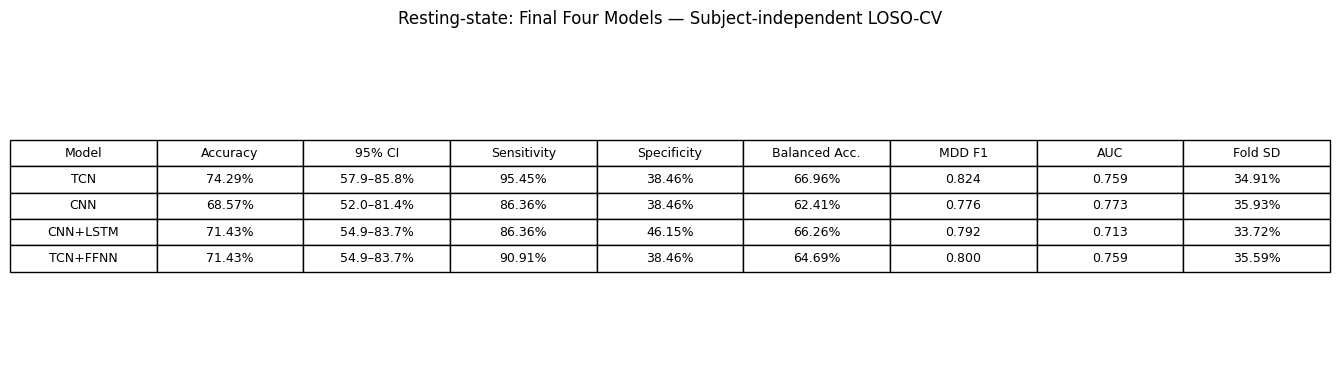

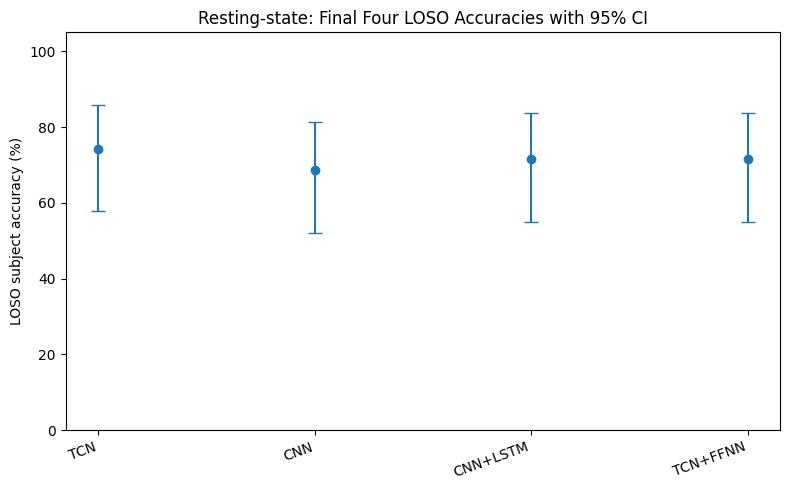

,Model,Accuracy,95% CI,Sensitivity,Specificity,Balanced Acc.,MDD F1,AUC,Fold SD
0,TCN,74.29%,57.9–85.8%,95.45%,38.46%,66.96%,0.824,0.759,34.91%
1,CNN,68.57%,52.0–81.4%,86.36%,38.46%,62.41%,0.776,0.773,35.93%
2,CNN+LSTM,71.43%,54.9–83.7%,86.36%,46.15%,66.26%,0.792,0.713,33.72%
3,TCN+FFNN,71.43%,54.9–83.7%,90.91%,38.46%,64.69%,0.800,0.759,35.59%



Saved combined CSV: /kaggle/working/LOSO_Q1_resting/model_results/Final_4_Model_Reviewer_Outputs/RESTING_FINAL_4_MODELS_LOSO_REVIEWER_TABLE.csv
Saved combined table PNG: /kaggle/working/LOSO_Q1_resting/model_results/Final_4_Model_Reviewer_Outputs/RESTING_FINAL_4_MODELS_LOSO_REVIEWER_TABLE.png
Saved accuracy CI PNG: /kaggle/working/LOSO_Q1_resting/model_results/Final_4_Model_Reviewer_Outputs/RESTING_FINAL_4_MODELS_LOSO_ACCURACY_CI.png


In [19]:
# ==============================================================
# REVIEWER-1 — FINAL 4-MODEL COMBINED LOSO RESULTS
# ==============================================================

FINAL_RESULTS_DIR = Path(RESULTS_ROOT) / "Final_4_Model_Reviewer_Outputs"
FINAL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)


def _safe_model_name(model_name):
    return (
        model_name
        .replace("+", "_")
        .replace(" ", "_")
        .replace("-", "_")
    )


def _wilson95(k, n, z=1.96):
    if n == 0:
        return np.nan, np.nan

    p = k / n
    den = 1 + z*z/n
    centre = (p + z*z/(2*n)) / den

    half = (
        z
        *
        np.sqrt(
            (
                p*(1-p)
                +
                z*z/(4*n)
            )
            /
            n
        )
        /
        den
    )

    return (
        float(max(0.0, centre-half)),
        float(min(1.0, centre+half))
    )


def summary_from_fold_csv(fold_path, model_name):
    d = pd.read_csv(fold_path)

    required = {
        "label",
        "subject_pred",
        "subject_prob",
        "window_accuracy",
        "subject_correct"
    }

    missing = required.difference(d.columns)

    if missing:
        raise ValueError(
            f"{fold_path} is missing columns required to reconstruct "
            f"the summary: {sorted(missing)}"
        )

    yt = d["label"].to_numpy(dtype=int)
    yp = d["subject_pred"].to_numpy(dtype=int)
    pr = d["subject_prob"].to_numpy(dtype=float)

    if len(yt) == 0:
        raise ValueError(f"No folds found in {fold_path}")

    tn, fp, fn, tp = confusion_matrix(
        yt,
        yp,
        labels=[0, 1]
    ).ravel()

    n = len(yt)
    n_mdd = int(tp + fn)
    n_hc = int(tn + fp)

    acc = float((tp + tn) / n)

    sensitivity = (
        float(tp / n_mdd)
        if n_mdd
        else np.nan
    )

    specificity = (
        float(tn / n_hc)
        if n_hc
        else np.nan
    )

    acc_ci = _wilson95(tp + tn, n)
    sens_ci = _wilson95(tp, n_mdd)
    spec_ci = _wilson95(tn, n_hc)

    auc = (
        float(roc_auc_score(yt, pr))
        if len(np.unique(yt)) == 2
        else np.nan
    )

    return pd.DataFrame(
        [{
            "model": model_name,
            "paradigm": "Resting-state",
            "n_subjects": int(n),
            "n_MDD": n_mdd,
            "n_HC": n_hc,

            "LOSO_subject_accuracy": acc,
            "accuracy_CI95_low": acc_ci[0],
            "accuracy_CI95_high": acc_ci[1],

            "sensitivity_MDD": sensitivity,
            "sensitivity_CI95_low": sens_ci[0],
            "sensitivity_CI95_high": sens_ci[1],

            "specificity_HC": specificity,
            "specificity_CI95_low": spec_ci[0],
            "specificity_CI95_high": spec_ci[1],

            "balanced_accuracy": float(
                balanced_accuracy_score(yt, yp)
            ),

            "precision_MDD": float(
                precision_score(
                    yt,
                    yp,
                    pos_label=1,
                    zero_division=0
                )
            ),

            "F1_MDD": float(
                f1_score(
                    yt,
                    yp,
                    pos_label=1,
                    zero_division=0
                )
            ),

            "macro_F1": float(
                f1_score(
                    yt,
                    yp,
                    average="macro",
                    zero_division=0
                )
            ),

            "subject_ROC_AUC": auc,

            "heldout_window_accuracy_mean": float(
                d["window_accuracy"].mean()
            ),

            "heldout_window_accuracy_SD": float(
                d["window_accuracy"].std(ddof=1)
            ),

            "subject_correct_indicator_SD": float(
                d["subject_correct"].std(ddof=1)
            ),

            "TN_subjects": int(tn),
            "FP_subjects": int(fp),
            "FN_subjects": int(fn),
            "TP_subjects": int(tp),

            "max_windows_per_subject": (
                "ALL"
                if MAX_WINDOWS_PER_SUBJECT is None
                else int(MAX_WINDOWS_PER_SUBJECT)
            )
        }]
    )


def current_summary_path(model_name):
    safe = _safe_model_name(model_name)

    if model_name == "TCN":
        return (
            Path(RESULTS_ROOT)
            /
            f"TCN_v3_{MAX_WINDOWS_PER_SUBJECT}w_layernorm_gap"
            /
            "TCN_v3_LOSO_summary.csv"
        )

    return (
        Path(RESULTS_ROOT)
        /
        "V4_separate_models"
        /
        safe
        /
        f"{safe}_LOSO_summary.csv"
    )


def current_fold_path(model_name):
    safe = _safe_model_name(model_name)

    if model_name == "TCN":
        return (
            Path(RESULTS_ROOT)
            /
            f"TCN_v3_{MAX_WINDOWS_PER_SUBJECT}w_layernorm_gap"
            /
            "TCN_v3_LOSO_folds.csv"
        )

    return (
        Path(RESULTS_ROOT)
        /
        "V4_separate_models"
        /
        safe
        /
        f"{safe}_LOSO_folds.csv"
    )


def exact_input_candidates(model_name, kind):
    safe = _safe_model_name(model_name)

    if model_name == "TCN":
        expected = (
            "TCN_v3_LOSO_summary.csv"
            if kind == "summary"
            else "TCN_v3_LOSO_folds.csv"
        )
    else:
        expected = (
            f"{safe}_LOSO_summary.csv"
            if kind == "summary"
            else f"{safe}_LOSO_folds.csv"
        )

    root = Path("/kaggle/input")

    if not root.exists():
        return []

    return sorted(
        root.rglob(expected)
    )


def resolve_model_result(model_name):
    # ----------------------------------------------------------
    # 1. Current working summary
    # ----------------------------------------------------------
    p = current_summary_path(model_name)

    if p.exists():
        print(f"{model_name}: using current summary -> {p}")
        return pd.read_csv(p), current_fold_path(model_name)


    # ----------------------------------------------------------
    # 2. Explicit external summary path
    # ----------------------------------------------------------
    ext = EXTERNAL_SUMMARY_PATHS.get(model_name)

    if ext:
        ext = Path(ext)

        if ext.exists():
            print(f"{model_name}: using external summary -> {ext}")
            return pd.read_csv(ext), (
                Path(EXTERNAL_FOLD_PATHS[model_name])
                if EXTERNAL_FOLD_PATHS.get(model_name)
                else None
            )

        print(f"WARNING: external summary does not exist: {ext}")


    # ----------------------------------------------------------
    # 3. Exact summary filename somewhere under /kaggle/input
    # ----------------------------------------------------------
    candidates = exact_input_candidates(
        model_name,
        "summary"
    )

    if len(candidates) == 1:
        print(
            f"{model_name}: automatically found saved summary -> "
            f"{candidates[0]}"
        )
        return pd.read_csv(candidates[0]), None

    if len(candidates) > 1:
        print(
            f"{model_name}: multiple saved summary candidates found."
        )

        for c in candidates:
            print("   ", c)

        print(
            "Set EXTERNAL_SUMMARY_PATHS explicitly if one of these "
            "is the result you want."
        )


    # ----------------------------------------------------------
    # 4. Current fold CSV -> reconstruct summary
    # ----------------------------------------------------------
    fold_p = current_fold_path(model_name)

    if fold_p.exists():
        print(
            f"{model_name}: summary missing, reconstructing from "
            f"current fold CSV -> {fold_p}"
        )

        return (
            summary_from_fold_csv(
                fold_p,
                model_name
            ),
            fold_p
        )


    # ----------------------------------------------------------
    # 5. Explicit external fold CSV -> reconstruct summary
    # ----------------------------------------------------------
    ext_fold = EXTERNAL_FOLD_PATHS.get(model_name)

    if ext_fold:
        ext_fold = Path(ext_fold)

        if ext_fold.exists():
            print(
                f"{model_name}: reconstructing from external fold CSV -> "
                f"{ext_fold}"
            )

            return (
                summary_from_fold_csv(
                    ext_fold,
                    model_name
                ),
                ext_fold
            )

        print(
            f"WARNING: external fold CSV does not exist: {ext_fold}"
        )


    # ----------------------------------------------------------
    # 6. Exact fold filename under /kaggle/input
    # ----------------------------------------------------------
    fold_candidates = exact_input_candidates(
        model_name,
        "fold"
    )

    if len(fold_candidates) == 1:
        print(
            f"{model_name}: automatically found saved fold CSV -> "
            f"{fold_candidates[0]}"
        )

        return (
            summary_from_fold_csv(
                fold_candidates[0],
                model_name
            ),
            fold_candidates[0]
        )

    if len(fold_candidates) > 1:
        print(
            f"{model_name}: multiple fold CSV candidates found."
        )

        for c in fold_candidates:
            print("   ", c)

        print(
            "Set EXTERNAL_FOLD_PATHS explicitly to choose the correct one."
        )


    return None, None


# ==============================================================
# COLLECT EXACTLY FOUR MODELS
# ==============================================================

summary_rows = []

resolved_fold_paths = {}

missing_models = []


for model_name in FINAL_FOUR_MODELS:
    summary, fold_path = resolve_model_result(
        model_name
    )

    if summary is None or len(summary) == 0:
        missing_models.append(
            model_name
        )
        continue

    row = summary.iloc[0].to_dict()

    # Normalize the displayed model name.
    row["model"] = model_name

    summary_rows.append(
        row
    )

    resolved_fold_paths[
        model_name
    ] = fold_path


combined4 = pd.DataFrame(
    summary_rows
)


if missing_models:
    print(
        "\nMISSING FINAL MODEL RESULTS:",
        missing_models
    )

    print(
        "Attach the saved Kaggle output/dataset and set its path in "
        "EXTERNAL_SUMMARY_PATHS or EXTERNAL_FOLD_PATHS."
    )


if len(combined4):

    order_map = {
        m: i
        for i, m in enumerate(
            FINAL_FOUR_MODELS
        )
    }

    combined4[
        "_order"
    ] = combined4[
        "model"
    ].map(
        order_map
    )

    combined4 = (
        combined4
        .sort_values(
            "_order"
        )
        .drop(
            columns=[
                "_order"
            ]
        )
        .reset_index(
            drop=True
        )
    )


    # Save machine-readable table.
    combined_csv = (
        FINAL_RESULTS_DIR
        /
        "RESTING_FINAL_4_MODELS_LOSO_REVIEWER_TABLE.csv"
    )

    combined4.to_csv(
        combined_csv,
        index=False
    )


    # Human-readable reviewer table.
    human4 = pd.DataFrame(
        {
            "Model":
                combined4[
                    "model"
                ],

            "Accuracy":
                (
                    100
                    *
                    combined4[
                        "LOSO_subject_accuracy"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),

            "95% CI":
                [
                    f"{100*l:.1f}–{100*h:.1f}%"
                    for l, h in zip(
                        combined4[
                            "accuracy_CI95_low"
                        ],
                        combined4[
                            "accuracy_CI95_high"
                        ]
                    )
                ],

            "Sensitivity":
                (
                    100
                    *
                    combined4[
                        "sensitivity_MDD"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),

            "Specificity":
                (
                    100
                    *
                    combined4[
                        "specificity_HC"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),

            "Balanced Acc.":
                (
                    100
                    *
                    combined4[
                        "balanced_accuracy"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                ),

            "MDD F1":
                combined4[
                    "F1_MDD"
                ].map(
                    lambda x:
                    f"{x:.3f}"
                ),

            "AUC":
                combined4[
                    "subject_ROC_AUC"
                ].map(
                    lambda x:
                    f"{x:.3f}"
                ),

            "Fold SD":
                (
                    100
                    *
                    combined4[
                        "heldout_window_accuracy_SD"
                    ]
                ).map(
                    lambda x:
                    f"{x:.2f}%"
                )
        }
    )


    fig, ax = plt.subplots(
        figsize=(
            13.5,
            max(
                3.4,
                1.2
                +
                0.65
                *
                len(
                    human4
                )
            )
        )
    )

    ax.axis(
        "off"
    )

    tab = ax.table(
        cellText=human4.values,
        colLabels=human4.columns,
        loc="center",
        cellLoc="center"
    )

    tab.auto_set_font_size(
        False
    )

    tab.set_fontsize(
        9
    )

    tab.scale(
        1,
        1.5
    )

    ax.set_title(
        "Resting-state: Final Four Models — Subject-independent LOSO-CV",
        pad=20
    )

    plt.tight_layout()

    combined_png = (
        FINAL_RESULTS_DIR
        /
        "RESTING_FINAL_4_MODELS_LOSO_REVIEWER_TABLE.png"
    )

    plt.savefig(
        combined_png,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    # Accuracy + 95% CI plot.
    acc = combined4[
        "LOSO_subject_accuracy"
    ].to_numpy(
        float
    )

    lo = combined4[
        "accuracy_CI95_low"
    ].to_numpy(
        float
    )

    hi = combined4[
        "accuracy_CI95_high"
    ].to_numpy(
        float
    )


    plt.figure(
        figsize=(
            8,
            5
        )
    )

    x = np.arange(
        len(
            combined4
        )
    )

    plt.errorbar(
        x,
        100
        *
        acc,
        yerr=100
        *
        np.vstack(
            [
                acc-lo,
                hi-acc
            ]
        ),
        fmt="o",
        capsize=5
    )

    plt.xticks(
        x,
        combined4[
            "model"
        ],
        rotation=20,
        ha="right"
    )

    plt.ylabel(
        "LOSO subject accuracy (%)"
    )

    plt.ylim(
        0,
        105
    )

    plt.title(
        "Resting-state: Final Four LOSO Accuracies with 95% CI"
    )

    plt.tight_layout()

    accuracy_png = (
        FINAL_RESULTS_DIR
        /
        "RESTING_FINAL_4_MODELS_LOSO_ACCURACY_CI.png"
    )

    plt.savefig(
        accuracy_png,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


    display(
        human4
    )

    print(
        "\nSaved combined CSV:",
        combined_csv
    )

    print(
        "Saved combined table PNG:",
        combined_png
    )

    print(
        "Saved accuracy CI PNG:",
        accuracy_png
    )

else:
    print(
        "No final model summaries were resolved."
    )

## Reviewer-3 — EEG biomarker / biological-significance analysis

This cell is independent of model training.

Primary subject-level biomarkers:

- global relative theta power: 4–8 Hz;
- broad frontal relative theta power;
- global relative alpha power: 8–13 Hz;
- global relative beta power: 13–30 Hz;
- broad frontal alpha asymmetry:
  `log(right alpha) - log(left alpha)`.

The relative-power denominator is 1–40 Hz. Frontal channel sets are derived from
the MNE HydroCel-128 montage geometry; the analysis does **not** claim these broad
sets are exact F3/F4 electrodes.

For each biomarker, the cell reports:

- MDD and HC mean ± SD;
- MDD–HC mean difference;
- Welch t statistic;
- Welch-Satterthwaite degrees of freedom;
- uncorrected p;
- BH-FDR q;
- Hedges' g;
- 95% CI of the mean difference.

These are group-level physiological associations and should not be interpreted
as causal mechanisms.

Biomarker windows per subject: 64
Biomarker output directory: /kaggle/working/LOSO_Q1_resting/model_results/Reviewer3_Biomarkers_Final
Broad left frontal channels: ['EEG 012', 'EEG 018', 'EEG 019', 'EEG 020', 'EEG 021', 'EEG 022', 'EEG 023', 'EEG 024', 'EEG 025', 'EEG 026', 'EEG 027', 'EEG 028', 'EEG 032', 'EEG 033']
Broad right frontal channels: ['EEG 001', 'EEG 002', 'EEG 003', 'EEG 004', 'EEG 005', 'EEG 008', 'EEG 009', 'EEG 010', 'EEG 014', 'EEG 117', 'EEG 118', 'EEG 122', 'EEG 123', 'EEG 124']


,subject,label,diagnosis,n_biomarker_windows,theta_relative_global,alpha_relative_global,beta_relative_global,theta_absolute_global,alpha_absolute_global,beta_absolute_global,frontal_theta_relative,FAA_log_right_minus_left
0,0201_0002,1,MDD,64,0.096073,0.300081,0.110900,7.788778e+12,2.051812e+13,7.788846e+12,0.092980,0.058081
1,0201_0004,1,MDD,64,0.096204,0.052739,0.076361,1.584016e+13,4.356926e+12,5.485338e+12,0.091753,0.233783
2,0201_0005,1,MDD,64,0.085006,0.091695,0.183992,1.925820e+13,1.242188e+13,2.495178e+13,0.084398,0.091582
3,0201_0006,1,MDD,64,0.064514,0.377814,0.133731,5.202854e+12,2.174444e+13,6.889457e+12,0.067591,-0.056053
4,0201_0008,1,MDD,64,0.081614,0.072545,0.041150,2.870452e+13,1.983865e+13,1.279714e+13,0.079432,0.021154


,biomarker,n_MDD,n_HC,MDD_mean,MDD_SD,HC_mean,HC_SD,mean_difference_MDD_minus_HC,mean_difference_CI95_low,mean_difference_CI95_high,Welch_t,Welch_df,p_uncorrected,Hedges_g_MDD_minus_HC,p_FDR_BH,FDR_significant_0.05
0,theta_relative_global,22,13,0.089124,0.019366,0.088359,0.026633,0.000765,-0.016912,0.018441,0.090349,19.578068,0.928928,0.033523,0.978444,False
1,frontal_theta_relative,22,13,0.088476,0.012735,0.089970,0.030385,-0.001493,-0.020418,0.017431,-0.168682,14.530933,0.868372,-0.069654,0.978444,False
2,alpha_relative_global,22,13,0.221227,0.145445,0.247562,0.162350,-0.026335,-0.139403,0.086733,-0.481682,23.110878,0.634561,-0.169498,0.978444,False
3,beta_relative_global,22,13,0.106481,0.046782,0.106906,0.043225,-0.000425,-0.032425,0.031574,-0.027271,26.976015,0.978444,-0.009129,0.978444,False
4,FAA_log_right_minus_left,22,13,0.025991,0.233702,-0.009851,0.284902,0.035843,-0.158151,0.229837,0.383694,21.497585,0.704973,0.138143,0.978444,False


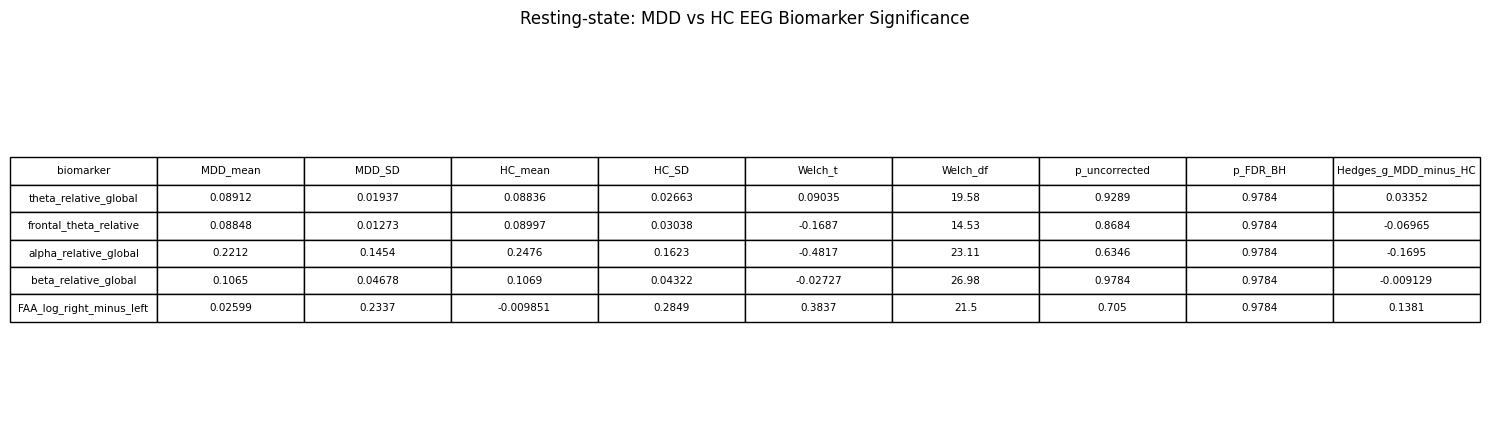

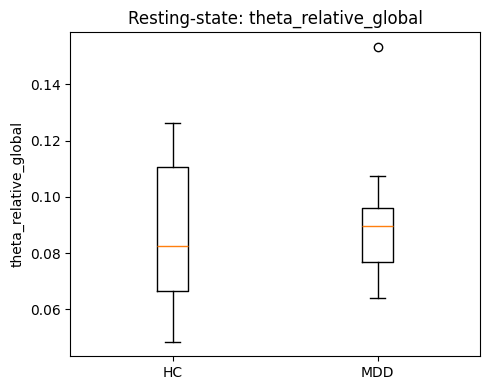

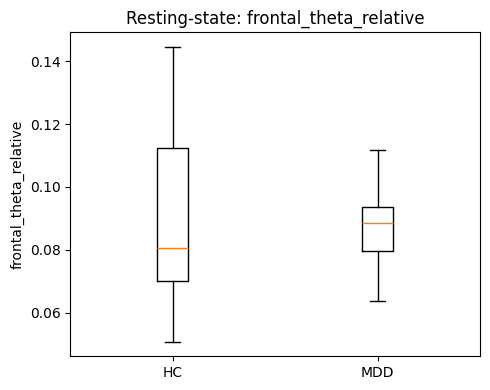

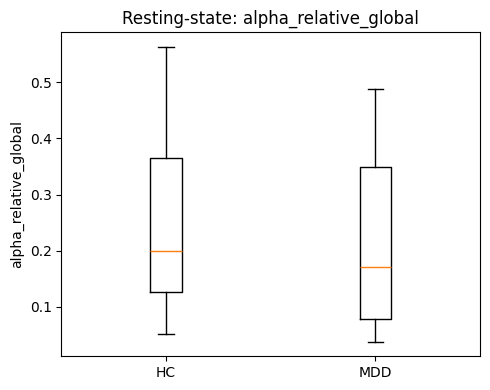

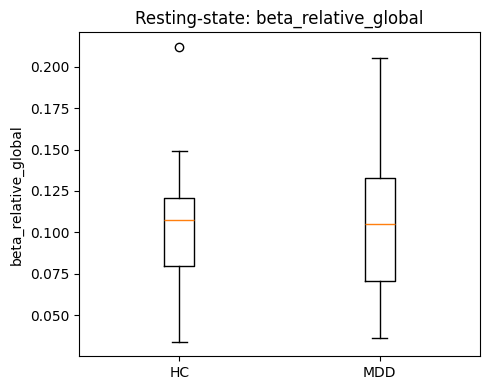

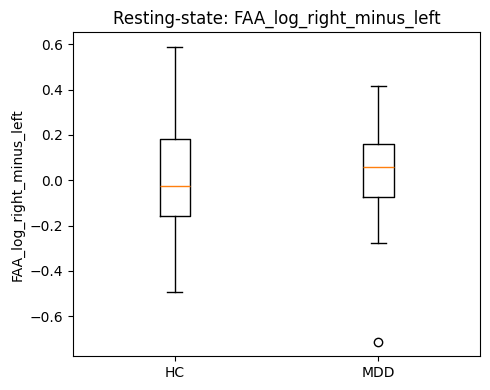


Saved subject biomarker CSV: /kaggle/working/LOSO_Q1_resting/model_results/Reviewer3_Biomarkers_Final/RESTING_subject_level_EEG_biomarkers.csv
Saved significance CSV: /kaggle/working/LOSO_Q1_resting/model_results/Reviewer3_Biomarkers_Final/RESTING_MDD_vs_HC_biomarker_statistics.csv
Saved biomarker outputs in: /kaggle/working/LOSO_Q1_resting/model_results/Reviewer3_Biomarkers_Final


In [20]:
# ==============================================================
# REVIEWER-3 — RESTING-STATE EEG BIOMARKER SIGNIFICANCE
# Fixed version: explicitly imports scipy.signal + scipy.stats
# ==============================================================

from scipy import signal, stats

BANDS = {
    "theta": (
        4.0,
        8.0
    ),

    "alpha": (
        8.0,
        13.0
    ),

    "beta": (
        13.0,
        30.0
    ),
}

TOTAL_POWER_BAND = (
    1.0,
    40.0
)

# Uniformly distributed windows per participant for a CPU-friendly
# physiological estimate.
BIO_WINDOWS = min(
    64,
    MAX_WINDOWS_PER_SUBJECT
    if MAX_WINDOWS_PER_SUBJECT is not None
    else 64
)

BIOMARKER_DIR = (
    Path(RESULTS_ROOT)
    /
    "Reviewer3_Biomarkers_Final"
)

BIOMARKER_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(
    "Biomarker windows per subject:",
    BIO_WINDOWS
)

print(
    "Biomarker output directory:",
    BIOMARKER_DIR
)


def _channel_number(ch):
    m = re.search(
        r"(\d{1,3})$",
        str(ch)
    )

    return (
        int(
            m.group(1)
        )
        if m
        else None
    )


def _frontal_channel_sets(channels):
    """
    Broad frontal left/right sets derived from HydroCel-128 geometry.

    We intentionally call these broad frontal sets, not F3/F4.
    """
    try:
        import mne

        montage = mne.channels.make_standard_montage(
            "GSN-HydroCel-128"
        )

        pos = montage.get_positions()[
            "ch_pos"
        ]

        rows = []

        for ch in channels:
            n = _channel_number(
                ch
            )

            key = (
                f"E{n}"
                if n is not None
                else None
            )

            if key in pos:
                x, y_coord, z = pos[
                    key
                ]

                rows.append(
                    [
                        str(ch),
                        n,
                        float(x),
                        float(y_coord),
                        float(z)
                    ]
                )

        geometry = pd.DataFrame(
            rows,
            columns=[
                "channel",
                "number",
                "x",
                "y",
                "z"
            ]
        )

        if len(
            geometry
        ) < 20:
            raise RuntimeError(
                "Too few channels matched the HydroCel montage."
            )

        # Anterior/high scalp region, then split by left/right x.
        anterior = geometry[
            (
                geometry[
                    "y"
                ]
                >=
                geometry[
                    "y"
                ].quantile(
                    0.70
                )
            )
            &
            (
                geometry[
                    "z"
                ]
                >=
                geometry[
                    "z"
                ].quantile(
                    0.20
                )
            )
        ].copy()

        left = anterior.loc[
            anterior[
                "x"
            ]
            <
            0,
            "channel"
        ].tolist()

        right = anterior.loc[
            anterior[
                "x"
            ]
            >
            0,
            "channel"
        ].tolist()

        geometry.to_csv(
            BIOMARKER_DIR
            /
            "HydroCel128_channel_geometry.csv",
            index=False
        )

        anterior.to_csv(
            BIOMARKER_DIR
            /
            "broad_frontal_channel_geometry.csv",
            index=False
        )

        return (
            left,
            right
        )

    except Exception as exc:
        print(
            "FAA/frontal montage unavailable:",
            exc
        )

        return (
            [],
            []
        )


def _integrate_band(
    psd,
    freqs,
    lo,
    hi
):
    mask = (
        (
            freqs
            >=
            lo
        )
        &
        (
            freqs
            <
            hi
        )
    )

    if np.sum(
        mask
    ) < 2:
        return np.full(
            psd.shape[
                -1
            ],
            np.nan,
            dtype=float
        )

    # np.trapezoid exists in newer NumPy; fall back for Kaggle versions.
    if hasattr(
        np,
        "trapezoid"
    ):
        return np.trapezoid(
            psd[
                mask
            ],
            freqs[
                mask
            ],
            axis=0
        )

    return np.trapz(
        psd[
            mask
        ],
        freqs[
            mask
        ],
        axis=0
    )


def _hedges_g(
    a,
    b
):
    a = np.asarray(
        a,
        dtype=float
    )

    b = np.asarray(
        b,
        dtype=float
    )

    n1 = len(
        a
    )

    n2 = len(
        b
    )

    if (
        n1 < 2
        or
        n2 < 2
    ):
        return np.nan

    v1 = np.var(
        a,
        ddof=1
    )

    v2 = np.var(
        b,
        ddof=1
    )

    pooled = (
        (
            (
                n1
                -
                1
            )
            *
            v1
            +
            (
                n2
                -
                1
            )
            *
            v2
        )
        /
        (
            n1
            +
            n2
            -
            2
        )
    )

    if (
        pooled
        <=
        0
        or
        not np.isfinite(
            pooled
        )
    ):
        return 0.0

    sp = np.sqrt(
        pooled
    )

    correction = (
        1
        -
        3
        /
        (
            4
            *
            (
                n1
                +
                n2
            )
            -
            9
        )
    )

    return float(
        correction
        *
        (
            (
                np.mean(
                    a
                )
                -
                np.mean(
                    b
                )
            )
            /
            sp
        )
    )


def _welch_df_and_ci(
    a,
    b,
    alpha=0.05
):
    """
    CI for mean(MDD) - mean(HC) using Welch unequal-variance SE/df.
    """
    a = np.asarray(
        a,
        dtype=float
    )

    b = np.asarray(
        b,
        dtype=float
    )

    n1 = len(
        a
    )

    n2 = len(
        b
    )

    v1 = np.var(
        a,
        ddof=1
    )

    v2 = np.var(
        b,
        ddof=1
    )

    term1 = (
        v1
        /
        n1
    )

    term2 = (
        v2
        /
        n2
    )

    se = np.sqrt(
        term1
        +
        term2
    )

    if (
        se == 0
        or
        not np.isfinite(
            se
        )
    ):
        diff = float(
            np.mean(
                a
            )
            -
            np.mean(
                b
            )
        )

        return (
            np.nan,
            diff,
            diff
        )

    df = (
        (
            term1
            +
            term2
        )
        **
        2
        /
        (
            (
                term1
                **
                2
            )
            /
            (
                n1
                -
                1
            )
            +
            (
                term2
                **
                2
            )
            /
            (
                n2
                -
                1
            )
        )
    )

    diff = float(
        np.mean(
            a
        )
        -
        np.mean(
            b
        )
    )

    crit = stats.t.ppf(
        1
        -
        alpha
        /
        2,
        df
    )

    low = float(
        diff
        -
        crit
        *
        se
    )

    high = float(
        diff
        +
        crit
        *
        se
    )

    return (
        float(
            df
        ),
        low,
        high
    )


def _bh_fdr(
    p_values
):
    p_values = np.asarray(
        p_values,
        dtype=float
    )

    q_values = np.full_like(
        p_values,
        np.nan,
        dtype=float
    )

    valid = np.isfinite(
        p_values
    )

    if not np.any(
        valid
    ):
        return q_values

    p = p_values[
        valid
    ]

    order = np.argsort(
        p
    )

    ranked = p[
        order
    ]

    m = len(
        ranked
    )

    adjusted = (
        ranked
        *
        m
        /
        np.arange(
            1,
            m
            +
            1
        )
    )

    adjusted = np.minimum.accumulate(
        adjusted[
            ::-1
        ]
    )[
        ::-1
    ]

    adjusted = np.minimum(
        adjusted,
        1.0
    )

    unsorted = np.empty_like(
        adjusted
    )

    unsorted[
        order
    ] = adjusted

    q_values[
        valid
    ] = unsorted

    return q_values


# ==============================================================
# BROAD FRONTAL SETS
# ==============================================================

left_frontal, right_frontal = _frontal_channel_sets(
    channel_names
)

channel_index = {
    str(
        c
    ): i
    for i, c in enumerate(
        channel_names
    )
}

left_idx = [
    channel_index[
        c
    ]
    for c in left_frontal
    if c in channel_index
]

right_idx = [
    channel_index[
        c
    ]
    for c in right_frontal
    if c in channel_index
]


frontal_sets_df = pd.DataFrame(
    {
        "hemisphere":
            (
                [
                    "left"
                ]
                *
                len(
                    left_frontal
                )
                +
                [
                    "right"
                ]
                *
                len(
                    right_frontal
                )
            ),

        "channel":
            left_frontal
            +
            right_frontal
    }
)

frontal_sets_df.to_csv(
    BIOMARKER_DIR
    /
    "broad_frontal_channel_sets.csv",
    index=False
)


print(
    "Broad left frontal channels:",
    left_frontal
)

print(
    "Broad right frontal channels:",
    right_frontal
)


# ==============================================================
# SUBJECT-LEVEL PSD / BIOMARKERS
# ==============================================================

subject_rows = []


for subject in np.unique(
    groups
):

    idx = np.where(
        groups
        ==
        subject
    )[0]


    if len(
        idx
    ) > BIO_WINDOWS:

        idx = idx[
            np.linspace(
                0,
                len(
                    idx
                )
                -
                1,
                BIO_WINDOWS,
                dtype=int
            )
        ]


    Xi = X[
        idx
    ].astype(
        np.float32
    ).copy()


    # Subject-local missing-value imputation only for descriptive PSD.
    channel_mean = np.nanmean(
        Xi.reshape(
            -1,
            Xi.shape[
                -1
            ]
        ),
        axis=0
    )


    channel_mean = np.where(
        np.isfinite(
            channel_mean
        ),
        channel_mean,
        0.0
    )


    for c in range(
        Xi.shape[
            -1
        ]
    ):
        bad = ~np.isfinite(
            Xi[
                ...,
                c
            ]
        )

        if np.any(
            bad
        ):
            Xi[
                ...,
                c
            ][
                bad
            ] = channel_mean[
                c
            ]


    # Remove window/channel DC component for PSD stability.
    Xi = (
        Xi
        -
        Xi.mean(
            axis=1,
            keepdims=True
        )
    )


    nperseg = min(
        Xi.shape[
            1
        ],
        int(
            2
            *
            FS
        )
    )


    freqs, psd = signal.welch(
        Xi,
        fs=FS,
        axis=1,
        nperseg=nperseg,
        detrend="constant",
        scaling="density"
    )


    # Average PSD across selected windows -> frequency x channel.
    psd = psd.mean(
        axis=0
    )


    total_abs = _integrate_band(
        psd,
        freqs,
        TOTAL_POWER_BAND[
            0
        ],
        TOTAL_POWER_BAND[
            1
        ]
    )


    total_abs = np.where(
        (
            np.isfinite(
                total_abs
            )
        )
        &
        (
            total_abs
            >
            1e-20
        ),
        total_abs,
        np.nan
    )


    abs_power = {}

    rel_power = {}


    for band_name, (
        lo,
        hi
    ) in BANDS.items():

        band_abs = _integrate_band(
            psd,
            freqs,
            lo,
            hi
        )


        abs_power[
            band_name
        ] = band_abs


        rel_power[
            band_name
        ] = (
            band_abs
            /
            total_abs
        )


    label = int(
        y[
            groups
            ==
            subject
        ][0]
    )


    result = {
        "subject":
            str(
                subject
            ),

        "label":
            label,

        "diagnosis":
            LABEL_NAMES[
                label
            ],

        "n_biomarker_windows":
            int(
                len(
                    idx
                )
            ),

        # Relative primary measures.
        "theta_relative_global":
            float(
                np.nanmean(
                    rel_power[
                        "theta"
                    ]
                )
            ),

        "alpha_relative_global":
            float(
                np.nanmean(
                    rel_power[
                        "alpha"
                    ]
                )
            ),

        "beta_relative_global":
            float(
                np.nanmean(
                    rel_power[
                        "beta"
                    ]
                )
            ),

        # Absolute values retained for transparency / sensitivity analysis.
        "theta_absolute_global":
            float(
                np.nanmean(
                    abs_power[
                        "theta"
                    ]
                )
            ),

        "alpha_absolute_global":
            float(
                np.nanmean(
                    abs_power[
                        "alpha"
                    ]
                )
            ),

        "beta_absolute_global":
            float(
                np.nanmean(
                    abs_power[
                        "beta"
                    ]
                )
            ),
    }


    if (
        left_idx
        and
        right_idx
    ):

        frontal_idx = (
            left_idx
            +
            right_idx
        )


        left_alpha = float(
            np.nanmean(
                abs_power[
                    "alpha"
                ][
                    left_idx
                ]
            )
        )


        right_alpha = float(
            np.nanmean(
                abs_power[
                    "alpha"
                ][
                    right_idx
                ]
            )
        )


        result[
            "frontal_theta_relative"
        ] = float(
            np.nanmean(
                rel_power[
                    "theta"
                ][
                    frontal_idx
                ]
            )
        )


        result[
            "FAA_log_right_minus_left"
        ] = float(
            np.log(
                right_alpha
                +
                1e-20
            )
            -
            np.log(
                left_alpha
                +
                1e-20
            )
        )

    else:

        result[
            "frontal_theta_relative"
        ] = np.nan


        result[
            "FAA_log_right_minus_left"
        ] = np.nan


    subject_rows.append(
        result
    )


biomarkers = pd.DataFrame(
    subject_rows
)


subject_bio_csv = (
    BIOMARKER_DIR
    /
    "RESTING_subject_level_EEG_biomarkers.csv"
)


biomarkers.to_csv(
    subject_bio_csv,
    index=False
)


display(
    biomarkers.head()
)


# ==============================================================
# GROUP-LEVEL SIGNIFICANCE
# ==============================================================

PRIMARY_BIOMARKERS = [
    "theta_relative_global",
    "frontal_theta_relative",
    "alpha_relative_global",
    "beta_relative_global",
    "FAA_log_right_minus_left",
]


stats_rows = []


for metric in PRIMARY_BIOMARKERS:

    mdd = (
        biomarkers.loc[
            biomarkers[
                "label"
            ]
            ==
            1,
            metric
        ]
        .dropna()
        .to_numpy(
            dtype=float
        )
    )


    hc = (
        biomarkers.loc[
            biomarkers[
                "label"
            ]
            ==
            0,
            metric
        ]
        .dropna()
        .to_numpy(
            dtype=float
        )
    )


    if (
        len(
            mdd
        ) < 2
        or
        len(
            hc
        ) < 2
    ):
        continue


    t_stat, p_value = stats.ttest_ind(
        mdd,
        hc,
        equal_var=False,
        nan_policy="omit"
    )


    welch_df, ci_low, ci_high = _welch_df_and_ci(
        mdd,
        hc
    )


    stats_rows.append(
        {
            "biomarker":
                metric,

            "n_MDD":
                int(
                    len(
                        mdd
                    )
                ),

            "n_HC":
                int(
                    len(
                        hc
                    )
                ),

            "MDD_mean":
                float(
                    np.mean(
                        mdd
                    )
                ),

            "MDD_SD":
                float(
                    np.std(
                        mdd,
                        ddof=1
                    )
                ),

            "HC_mean":
                float(
                    np.mean(
                        hc
                    )
                ),

            "HC_SD":
                float(
                    np.std(
                        hc,
                        ddof=1
                    )
                ),

            "mean_difference_MDD_minus_HC":
                float(
                    np.mean(
                        mdd
                    )
                    -
                    np.mean(
                        hc
                    )
                ),

            "mean_difference_CI95_low":
                ci_low,

            "mean_difference_CI95_high":
                ci_high,

            "Welch_t":
                float(
                    t_stat
                ),

            "Welch_df":
                welch_df,

            "p_uncorrected":
                float(
                    p_value
                ),

            "Hedges_g_MDD_minus_HC":
                _hedges_g(
                    mdd,
                    hc
                )
        }
    )


biomarker_stats = pd.DataFrame(
    stats_rows
)


if len(
    biomarker_stats
):

    biomarker_stats[
        "p_FDR_BH"
    ] = _bh_fdr(
        biomarker_stats[
            "p_uncorrected"
        ].to_numpy(
            dtype=float
        )
    )


    biomarker_stats[
        "FDR_significant_0.05"
    ] = (
        biomarker_stats[
            "p_FDR_BH"
        ]
        <
        0.05
    )


stats_csv = (
    BIOMARKER_DIR
    /
    "RESTING_MDD_vs_HC_biomarker_statistics.csv"
)


biomarker_stats.to_csv(
    stats_csv,
    index=False
)


display(
    biomarker_stats
)


# ==============================================================
# REVIEWER TABLE PNG
# ==============================================================

if len(
    biomarker_stats
):

    show = biomarker_stats[
        [
            "biomarker",
            "MDD_mean",
            "MDD_SD",
            "HC_mean",
            "HC_SD",
            "Welch_t",
            "Welch_df",
            "p_uncorrected",
            "p_FDR_BH",
            "Hedges_g_MDD_minus_HC"
        ]
    ].copy()


    for col in show.columns[
        1:
    ]:
        show[
            col
        ] = show[
            col
        ].map(
            lambda x:
            f"{x:.4g}"
            if pd.notna(
                x
            )
            else ""
        )


    fig, ax = plt.subplots(
        figsize=(
            15,
            4.5
        )
    )


    ax.axis(
        "off"
    )


    table = ax.table(
        cellText=show.values,
        colLabels=show.columns,
        loc="center",
        cellLoc="center"
    )


    table.auto_set_font_size(
        False
    )


    table.set_fontsize(
        7.5
    )


    table.scale(
        1,
        1.5
    )


    ax.set_title(
        "Resting-state: MDD vs HC EEG Biomarker Significance",
        pad=18
    )


    plt.tight_layout()


    stats_png = (
        BIOMARKER_DIR
        /
        "RESTING_MDD_vs_HC_biomarker_statistics.png"
    )


    plt.savefig(
        stats_png,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


# ==============================================================
# INDIVIDUAL BIOMARKER BOXPLOTS
# ==============================================================

for metric in PRIMARY_BIOMARKERS:

    if (
        metric
        not in biomarkers.columns
        or
        biomarkers[
            metric
        ].isna().all()
    ):
        continue


    hc_values = biomarkers.loc[
        biomarkers[
            "label"
        ]
        ==
        0,
        metric
    ].dropna()


    mdd_values = biomarkers.loc[
        biomarkers[
            "label"
        ]
        ==
        1,
        metric
    ].dropna()


    plt.figure(
        figsize=(
            5,
            4
        )
    )


    plt.boxplot(
        [
            hc_values,
            mdd_values
        ],
        tick_labels=[
            "HC",
            "MDD"
        ]
    )


    plt.ylabel(
        metric
    )


    plt.title(
        f"Resting-state: {metric}"
    )


    plt.tight_layout()


    plt.savefig(
        BIOMARKER_DIR
        /
        f"RESTING_{metric}.png",
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


print(
    "\nSaved subject biomarker CSV:",
    subject_bio_csv
)

print(
    "Saved significance CSV:",
    stats_csv
)

print(
    "Saved biomarker outputs in:",
    BIOMARKER_DIR
)

## Reviewer-3 — four-model probability ↔ biomarker association

This optional cell connects the **held-out LOSO MDD probability** from each final
model with the subject-level EEG biomarkers using Spearman correlation.

This is useful as biological corroboration, but it is **not** equivalent to proving
that a biomarker is a causal or high-weight internal feature of the neural network.

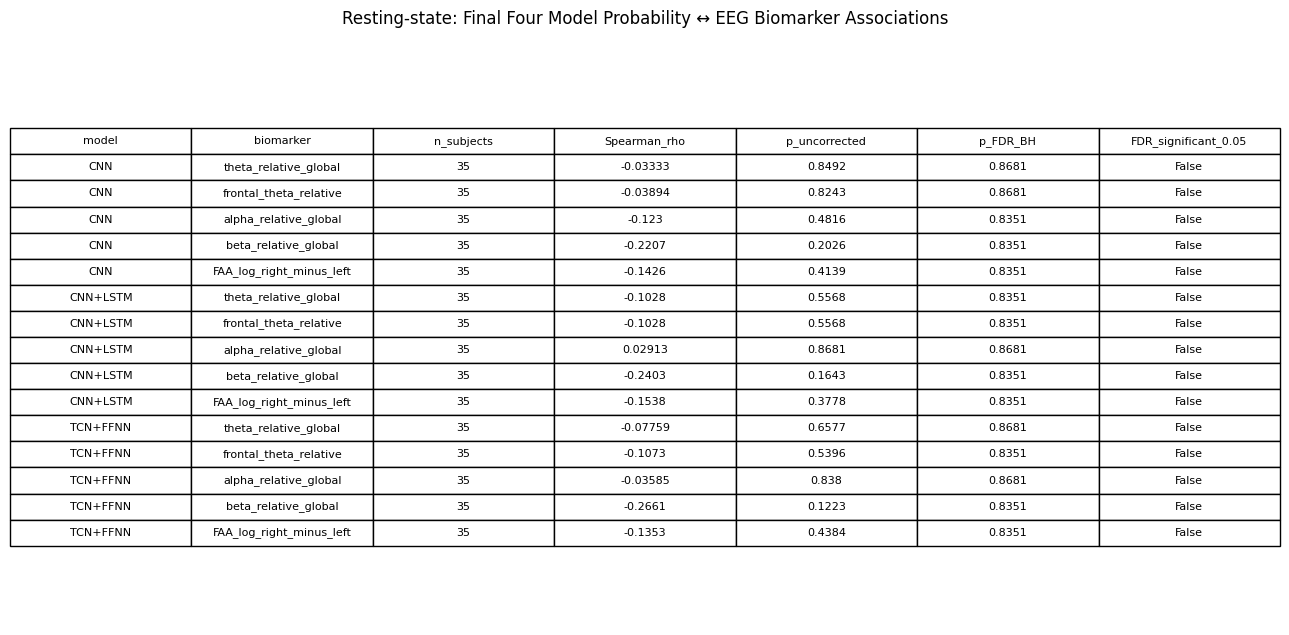

,model,biomarker,n_subjects,Spearman_rho,p_uncorrected,p_FDR_BH,FDR_significant_0.05
0,CNN,theta_relative_global,35,-0.033333,0.849236,0.868062,False
1,CNN,frontal_theta_relative,35,-0.038936,0.824264,0.868062,False
2,CNN,alpha_relative_global,35,-0.122969,0.481587,0.835148,False
3,CNN,beta_relative_global,35,-0.220728,0.202590,0.835148,False
4,CNN,FAA_log_right_minus_left,35,-0.142577,0.413900,0.835148,False
5,CNN+LSTM,theta_relative_global,35,-0.102801,0.556765,0.835148,False
6,CNN+LSTM,frontal_theta_relative,35,-0.102801,0.556765,0.835148,False
7,CNN+LSTM,alpha_relative_global,35,0.029132,0.868062,0.868062,False
8,CNN+LSTM,beta_relative_global,35,-0.240336,0.164319,0.835148,False
9,CNN+LSTM,FAA_log_right_minus_left,35,-0.153782,0.377774,0.835148,False


Saved association CSV: /kaggle/working/LOSO_Q1_resting/model_results/Reviewer3_Model_Biomarker_Associations_Final4/RESTING_FINAL4_model_probability_biomarker_associations.csv
Saved association PNG: /kaggle/working/LOSO_Q1_resting/model_results/Reviewer3_Model_Biomarker_Associations_Final4/RESTING_FINAL4_model_probability_biomarker_associations.png


In [21]:
# ==============================================================
# REVIEWER-3 — MODEL PROBABILITY / BIOMARKER ASSOCIATIONS
# Exactly the final four models.
# ==============================================================

ASSOC_DIR = (
    Path(RESULTS_ROOT)
    /
    "Reviewer3_Model_Biomarker_Associations_Final4"
)

ASSOC_DIR.mkdir(
    parents=True,
    exist_ok=True
)


association_rows = []

merged_model_tables = []


for model_name in FINAL_FOUR_MODELS:

    # Reuse the fold path resolved in the combined-results cell.
    fold_path = resolved_fold_paths.get(
        model_name
    )


    # If the combined cell got a summary but no fold path, try again here.
    if (
        fold_path is None
        or
        not Path(
            fold_path
        ).exists()
    ):

        candidate = current_fold_path(
            model_name
        )


        if candidate.exists():

            fold_path = candidate

        elif EXTERNAL_FOLD_PATHS.get(
            model_name
        ):

            candidate = Path(
                EXTERNAL_FOLD_PATHS[
                    model_name
                ]
            )

            if candidate.exists():
                fold_path = candidate


    if (
        fold_path is None
        or
        not Path(
            fold_path
        ).exists()
    ):

        print(
            f"{model_name}: fold CSV unavailable; "
            "skipping model-biomarker association."
        )

        continue


    folds = pd.read_csv(
        fold_path
    )


    if not {
        "subject",
        "subject_prob"
    }.issubset(
        folds.columns
    ):

        print(
            f"{model_name}: fold CSV lacks subject/subject_prob; skipping."
        )

        continue


    model_subjects = folds[
        [
            "subject",
            "subject_prob"
        ]
    ].copy()


    model_subjects[
        "subject"
    ] = model_subjects[
        "subject"
    ].astype(
        str
    )


    model_subjects = model_subjects.rename(
        columns={
            "subject_prob":
                "model_MDD_probability"
        }
    )


    merged = biomarkers.copy()


    merged[
        "subject"
    ] = merged[
        "subject"
    ].astype(
        str
    )


    merged = merged.merge(
        model_subjects,
        on="subject",
        how="inner"
    )


    merged[
        "model"
    ] = model_name


    merged_model_tables.append(
        merged
    )


    for metric in PRIMARY_BIOMARKERS:

        d = merged[
            [
                "model_MDD_probability",
                metric
            ]
        ].dropna()


        if len(
            d
        ) < 5:
            continue


        rho, p_value = stats.spearmanr(
            d[
                "model_MDD_probability"
            ],
            d[
                metric
            ]
        )


        association_rows.append(
            {
                "model":
                    model_name,

                "biomarker":
                    metric,

                "n_subjects":
                    int(
                        len(
                            d
                        )
                    ),

                "Spearman_rho":
                    float(
                        rho
                    ),

                "p_uncorrected":
                    float(
                        p_value
                    )
            }
        )


associations = pd.DataFrame(
    association_rows
)


if len(
    associations
):

    associations[
        "p_FDR_BH"
    ] = _bh_fdr(
        associations[
            "p_uncorrected"
        ].to_numpy(
            dtype=float
        )
    )


    associations[
        "FDR_significant_0.05"
    ] = (
        associations[
            "p_FDR_BH"
        ]
        <
        0.05
    )


    assoc_csv = (
        ASSOC_DIR
        /
        "RESTING_FINAL4_model_probability_biomarker_associations.csv"
    )


    associations.to_csv(
        assoc_csv,
        index=False
    )


    show = associations.copy()


    for col in [
        "Spearman_rho",
        "p_uncorrected",
        "p_FDR_BH"
    ]:

        show[
            col
        ] = show[
            col
        ].map(
            lambda x:
            f"{x:.4g}"
            if pd.notna(
                x
            )
            else ""
        )


    fig, ax = plt.subplots(
        figsize=(
            13,
            max(
                4,
                1.2
                +
                0.35
                *
                len(
                    show
                )
            )
        )
    )


    ax.axis(
        "off"
    )


    table = ax.table(
        cellText=show.values,
        colLabels=show.columns,
        loc="center",
        cellLoc="center"
    )


    table.auto_set_font_size(
        False
    )


    table.set_fontsize(
        8
    )


    table.scale(
        1,
        1.35
    )


    ax.set_title(
        "Resting-state: Final Four Model Probability ↔ EEG Biomarker Associations",
        pad=18
    )


    plt.tight_layout()


    assoc_png = (
        ASSOC_DIR
        /
        "RESTING_FINAL4_model_probability_biomarker_associations.png"
    )


    plt.savefig(
        assoc_png,
        dpi=300,
        bbox_inches="tight"
    )


    plt.show()


    display(
        associations
    )


    print(
        "Saved association CSV:",
        assoc_csv
    )


    print(
        "Saved association PNG:",
        assoc_png
    )

else:

    print(
        "No model-biomarker associations could be calculated. "
        "This usually means the per-fold CSVs were not available."
    )